# Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import argrelextrema
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
import requests
import time

# Data preparation

In [2]:
file_path = "/Users/carlotagomezmontes/Desktop/5th 2nd /FT DATA/Algorithm/Corn data.xlsx"  
xls = pd.ExcelFile(file_path)

In [3]:
dataframes = []

for sheet in xls.sheet_names:
    df = pd.read_excel(xls, sheet_name=sheet)

    df = df.iloc[1:].copy()

    df.columns = ["Contract", "Date", "Price"]

    df["Date"] = pd.to_datetime(df["Date"])

    df.drop(columns=["Contract"], inplace=True)
    
    df["Contract_Expiration"] = sheet

    dataframes.append(df)

In [4]:
df_combined = pd.concat(dataframes, ignore_index=True)

df_combined.set_index("Date", inplace=True)

df_combined.sort_index(inplace=True)


In [5]:
df_combined.to_csv("organized_corn_futures_data.csv")

In [6]:
print(df_combined.dtypes) 
print(df_combined.nunique())
print(df_combined.head())

Price                  float64
Contract_Expiration     object
dtype: object
Price                  2523
Contract_Expiration     135
dtype: int64
             Price Contract_Expiration
Date                                  
2000-01-04  241.00               mar 1
2000-01-04  253.75               dec 1
2000-01-04  216.50               jul 0
2000-01-04  209.75               may 0
2000-01-04  223.25               sep 0


# Technical Indicators

In [7]:
def compute_technical_indicators(df):
    
    df = df.copy()

    if "Price" not in df.columns:
        raise KeyError("Error: 'Price' column not found in the dataset!")

    df["SMA_20"] = df["Price"].rolling(window=20).mean()
    df["SMA_50"] = df["Price"].rolling(window=50).mean()
    df["SMA_200"] = df["Price"].rolling(window=200).mean()

    df["RSI"] = compute_rsi(df)

    df = compute_bollinger_bands(df)

    df = compute_fibonacci_levels(df)

    df = compute_macd(df)

    df = compute_stochastic_oscillator(df)

    df.fillna(method="bfill", inplace=True) 

    return df


def compute_rsi(df, period=14):
    
    delta = df["Price"].diff(1)
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    
    rs = gain / loss
    df["RSI"] = 100 - (100 / (1 + rs))
    
    return df["RSI"]

def compute_bollinger_bands(df, window=20):
    
    df["BB_Middle"] = df["Price"].rolling(window=window).mean()
    df["BB_Upper"] = df["BB_Middle"] + (2 * df["Price"].rolling(window=window).std())
    df["BB_Lower"] = df["BB_Middle"] - (2 * df["Price"].rolling(window=window).std())
    
    return df

def compute_fibonacci_levels(df, window=15):
    
    df = df.copy()
    
    df["High_Max"] = df["Price"].rolling(window=window).max()
    df["Low_Min"] = df["Price"].rolling(window=window).min()
    
    df["Fib_38.2"] = df["High_Max"] - (0.382 * (df["High_Max"] - df["Low_Min"]))
    df["Fib_50"] = df["High_Max"] - (0.50 * (df["High_Max"] - df["Low_Min"]))
    df["Fib_61.8"] = df["High_Max"] - (0.618 * (df["High_Max"] - df["Low_Min"]))
    
    return df

def compute_stochastic_oscillator(df, period=14):
    
    df = df.copy()
    df["Lowest_Low"] = df["Price"].rolling(window=period, min_periods=1).min()
    df["Highest_High"] = df["Price"].rolling(window=period, min_periods=1).max()
    
    df["Stochastic_%K"] = 100 * ((df["Price"] - df["Lowest_Low"]) / (df["Highest_High"] - df["Lowest_Low"]))
    
    return df

def compute_macd(df, short_window=12, long_window=26, signal_window=9):
    
    df = df.copy()
    
    if "Price" not in df.columns:
        raise KeyError("Error: 'Price' column not found in the dataset!")

    df["MACD"] = df["Price"].ewm(span=short_window, adjust=False).mean() - df["Price"].ewm(span=long_window, adjust=False).mean()
    
    df["MACD_Signal"] = df["MACD"].ewm(span=signal_window, adjust=False).mean()
    
    return df



In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from scipy.signal import argrelextrema


def classify_market_trend(df):
    df["Market_Trend"] = np.where(
        (df["SMA_50"] > df["SMA_200"]) & (df["RSI"].diff() > 0), 1, 
        np.where(
            (df["SMA_50"] < df["SMA_200"]) & (df["RSI"].diff() < 0), -1, 
            0 
        )
    )
    return df


def detect_support_resistance(df, window=20):
    
    df["Support_Level"] = df["Price"].rolling(window).min()
    df["Resistance_Level"] = df["Price"].rolling(window).max()

    df["Support_Break"] = df["Price"] < df["Support_Level"]
    df["Resistance_Break"] = df["Price"] > df["Resistance_Level"]

    return df


def calculate_trading_score(df):
    
    weights = {
        "Trend": 0.4,  
        "SMA_Cross": 0.3,  
        "Support_Resistance": 0.2,  
        "RSI": 0.1  
    }

    df["SMA_Cross_Signal"] = np.where(df["SMA_20"] > df["SMA_50"], 1, -1)  
    df["Support_Res_Signal"] = np.where(df["Support_Break"], -1, np.where(df["Resistance_Break"], 1, 0))  
    df["RSI_Signal"] = np.where(df["RSI"] < 30, 1, np.where(df["RSI"] > 70, -1, 0))  

    df["Technical_Score"] = (
        df["Market_Trend"] * weights["Trend"] +
        df["SMA_Cross_Signal"] * weights["SMA_Cross"] +
        df["Support_Res_Signal"] * weights["Support_Resistance"] +
        df["RSI_Signal"] * weights["RSI"]
    )

    buy_threshold = 0.5
    sell_threshold = -0.5

    df["Buy_Signal"] = df["Technical_Score"] >= buy_threshold
    df["Sell_Signal"] = df["Technical_Score"] <= sell_threshold

    return df


In [9]:
def generate_long_term_trading_signals(df):
   
    df = df.copy()

    df["Buy_Signal"] = False
    df["Sell_Signal"] = False

    df["Buy_Signal"] |= (
        (df["Price"] >= df["Fib_38.2"]) & 
        (df["Price"] <= df["Fib_61.8"]) &
        (df["Price"].rolling(10).mean() >= df["Fib_38.2"]) & 
        (df["SMA_50"] > df["SMA_200"]) & 
        (df["SMA_50"].rolling(15).mean() > df["SMA_200"].rolling(15).mean()) 
    )

    df["Sell_Signal"] |= (
        (df["Price"] < df["Fib_38.2"]) & 
        (df["SMA_50"] < df["SMA_200"]) &  
        (df["SMA_50"].rolling(15).mean() < df["SMA_200"].rolling(15).mean()) &  
        (df["RSI"] > 70)
    )

    df["Buy_Signal"] |= (
        (df["Price"].rolling(10).mean() >= df["BB_Lower"]) & 
        (df["RSI"] < 30)  
    )
    
    df["Sell_Signal"] |= (
        (df["Price"].rolling(10).mean() >= df["BB_Upper"]) & 
        (df["RSI"] > 70)  
    )

    df["Buy_Signal"] |= (
        (df["SMA_50"].rolling(30).mean() > df["SMA_200"].rolling(30).mean()) &  
        (df["Price"].rolling(20).mean() > df["SMA_50"]) 
    )
    
    df["Sell_Signal"] |= (
        (df["SMA_50"].rolling(30).mean() < df["SMA_200"].rolling(30).mean()) &
        (df["Price"].rolling(20).mean() < df["SMA_50"]) 
    )

    df["Buy_Signal"] |= (
        (df["MACD"] > df["MACD"].rolling(5).mean()) & 
        (df["Stochastic_%K"] < 20) 
    )
    
    df["Sell_Signal"] |= (
        (df["MACD"] < df["MACD"].rolling(5).mean()) &  
        (df["Stochastic_%K"] > 80) 
    )

    df["Buy_Signal"] |= (
        (df["Price"].rolling(15).mean() > df["BB_Upper"]) &  
        (df["RSI"] > 50)  
    )

    df["Sell_Signal"] |= (
        (df["Price"].rolling(15).mean() < df["BB_Lower"]) & 
        (df["RSI"] < 50)  
    )

    return df

df_combined = compute_technical_indicators(df_combined)

print("Updated Columns in df_combined:", df_combined.columns) 

df_combined = generate_long_term_trading_signals(df_combined)

print(df_combined[["Price", "MACD", "MACD_Signal", "Fib_38.2", "SMA_50", "RSI", "Buy_Signal", "Sell_Signal"]].tail(20))


Updated Columns in df_combined: Index(['Price', 'Contract_Expiration', 'SMA_20', 'SMA_50', 'SMA_200', 'RSI',
       'BB_Middle', 'BB_Upper', 'BB_Lower', 'High_Max', 'Low_Min', 'Fib_38.2',
       'Fib_50', 'Fib_61.8', 'MACD', 'MACD_Signal', 'Lowest_Low',
       'Highest_High', 'Stochastic_%K'],
      dtype='object')
             Price      MACD  MACD_Signal  Fib_38.2   SMA_50        RSI  \
Date                                                                      
2025-02-07  485.25  2.572019     1.504019  494.0375  481.150  53.189189   
2025-02-07  500.50  3.447533     1.892722  494.0375  481.225  51.620112   
2025-02-07  482.75  2.678234     2.049825  494.0375  481.445  49.306297   
2025-02-07  467.00  0.788576     1.797575  494.0375  481.580  41.837838   
2025-02-07  466.50 -0.740798     1.289900  493.8465  481.705  48.618090   
2025-02-07  504.50  1.100756     1.252072  493.8465  482.545  57.401491   
2025-02-07  466.00 -0.540200     0.893617  493.6555  482.305  47.238095   
2025-02-

# Exploratory analysis

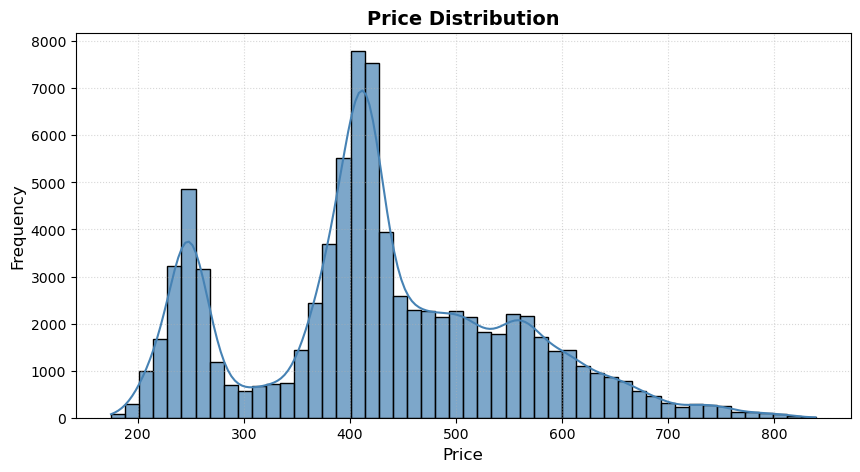

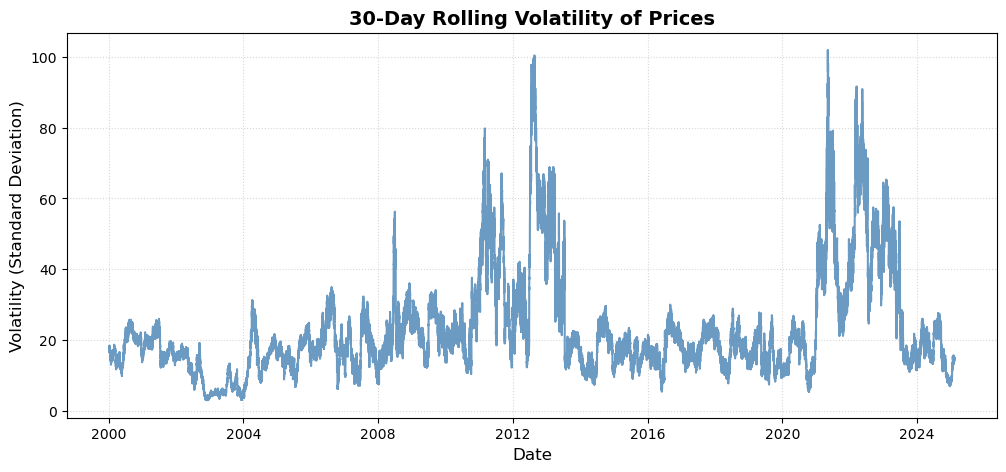

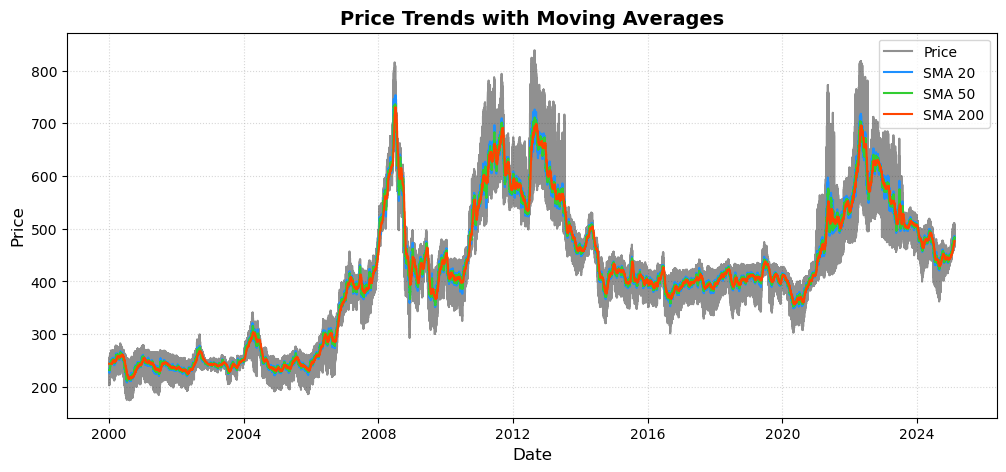

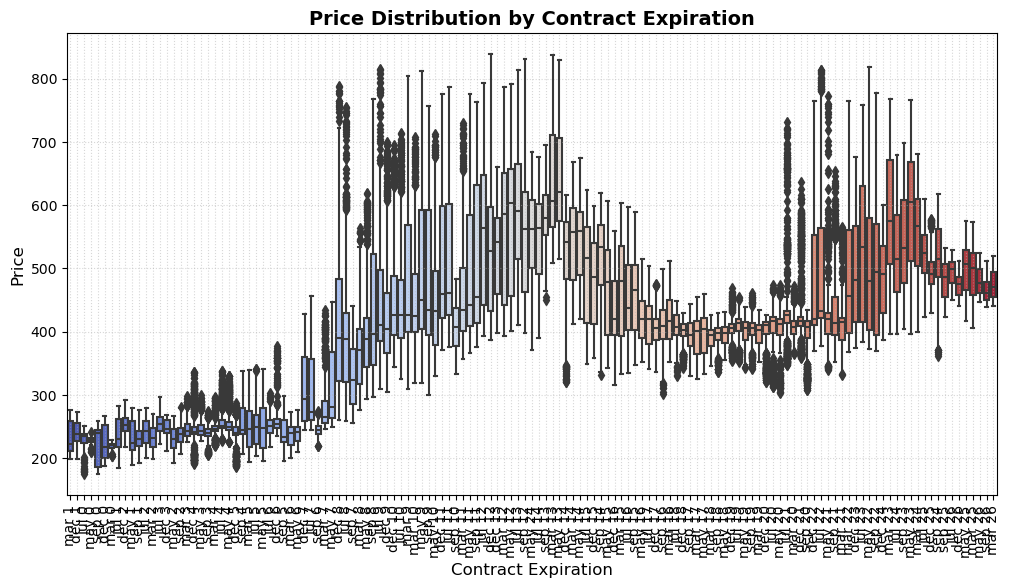

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(df_combined["Price"], bins=50, kde=True, color="#4682B4", alpha=0.7)
plt.title("Price Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Price", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(True, linestyle="dotted", alpha=0.5)
plt.show()

plt.figure(figsize=(12, 5))
df_combined["Rolling_Volatility"] = df_combined["Price"].rolling(window=30).std() 
plt.plot(df_combined.index, df_combined["Rolling_Volatility"], color="#4682B4", linewidth=1.5, alpha=0.8)
plt.title("30-Day Rolling Volatility of Prices", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Volatility (Standard Deviation)", fontsize=12)
plt.grid(True, linestyle="dotted", alpha=0.5)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df_combined.index, df_combined["Price"], label="Price", color="#222222", alpha=0.5)
plt.plot(df_combined.index, df_combined["SMA_20"], label="SMA 20", color="#1E90FF", linewidth=1.5)
plt.plot(df_combined.index, df_combined["SMA_50"], label="SMA 50", color="#32CD32", linewidth=1.5)
plt.plot(df_combined.index, df_combined["SMA_200"], label="SMA 200", color="#FF4500", linewidth=1.5)
plt.title("Price Trends with Moving Averages", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.legend()
plt.grid(True, linestyle="dotted", alpha=0.5)
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x="Contract_Expiration", y="Price", data=df_combined, palette="coolwarm")
plt.xticks(rotation=90)
plt.title("Price Distribution by Contract Expiration", fontsize=14, fontweight="bold")
plt.xlabel("Contract Expiration", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.grid(True, linestyle="dotted", alpha=0.5)
plt.show()


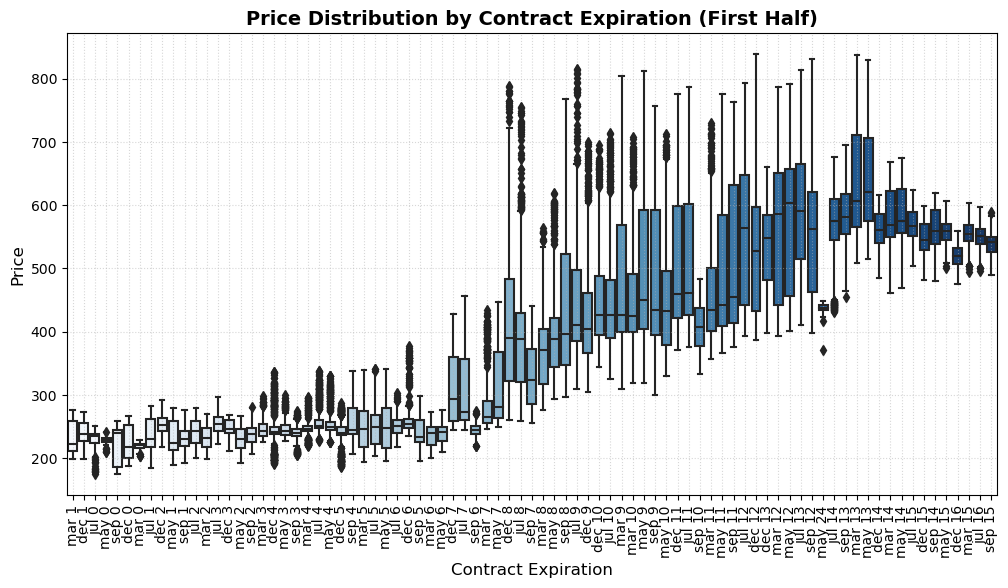

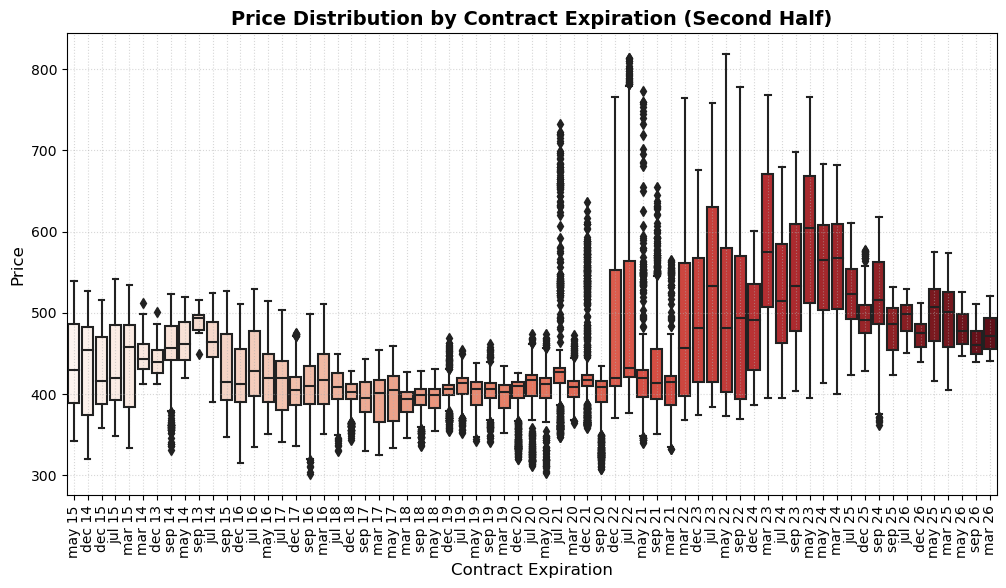

In [11]:
mid_point = df_combined.index[int(len(df_combined) / 2)]
df_first_half = df_combined[df_combined.index <= mid_point]
df_second_half = df_combined[df_combined.index > mid_point]

plt.figure(figsize=(12, 6))
sns.boxplot(x="Contract_Expiration", y="Price", data=df_first_half, palette="Blues")
plt.xticks(rotation=90)
plt.title("Price Distribution by Contract Expiration (First Half)", fontsize=14, fontweight="bold")
plt.xlabel("Contract Expiration", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.grid(True, linestyle="dotted", alpha=0.5)
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x="Contract_Expiration", y="Price", data=df_second_half, palette="Reds")
plt.xticks(rotation=90)
plt.title("Price Distribution by Contract Expiration (Second Half)", fontsize=14, fontweight="bold")
plt.xlabel("Contract Expiration", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.grid(True, linestyle="dotted", alpha=0.5)
plt.show()


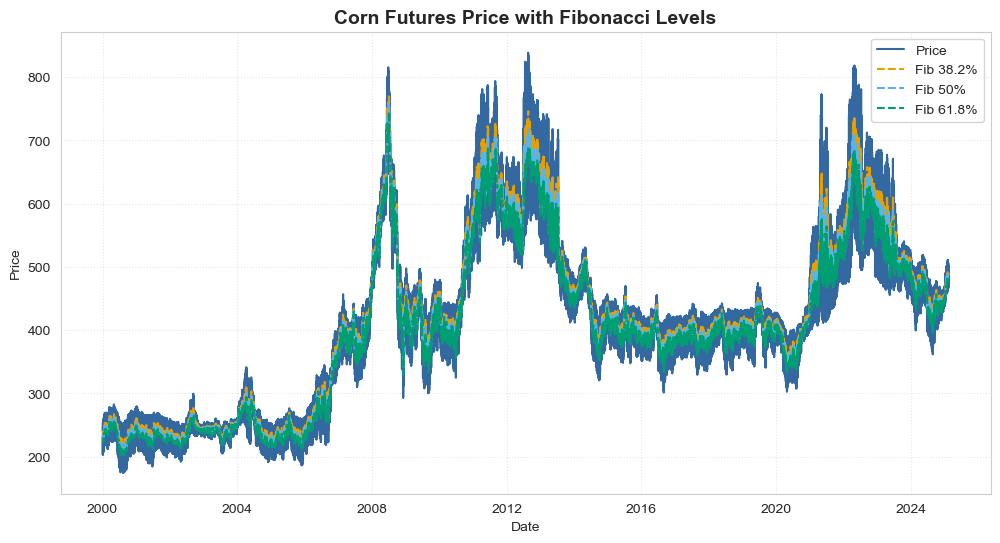

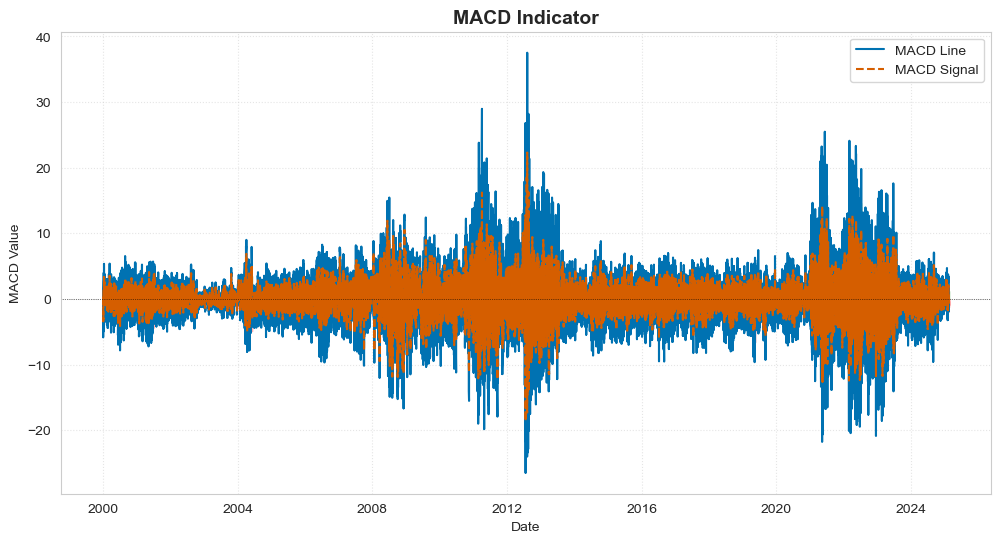

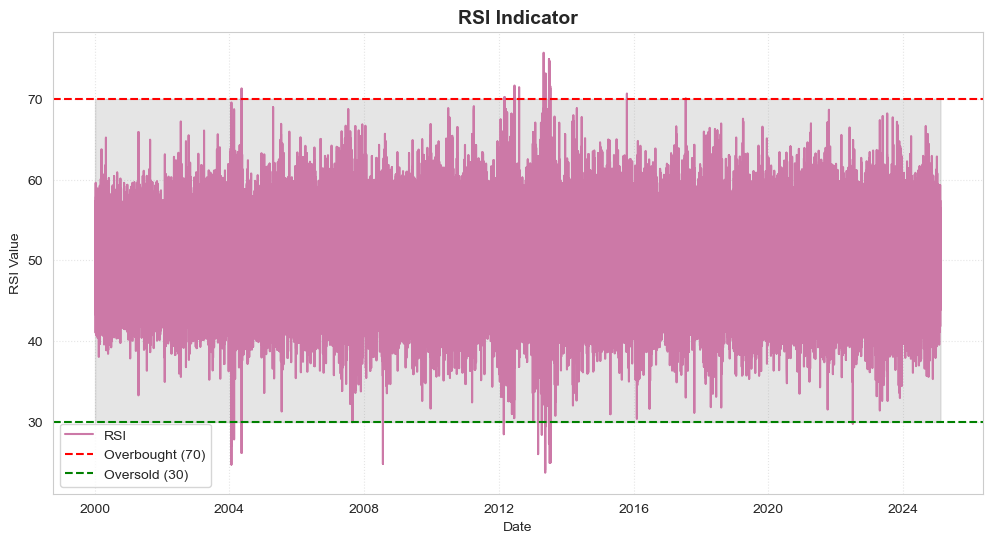

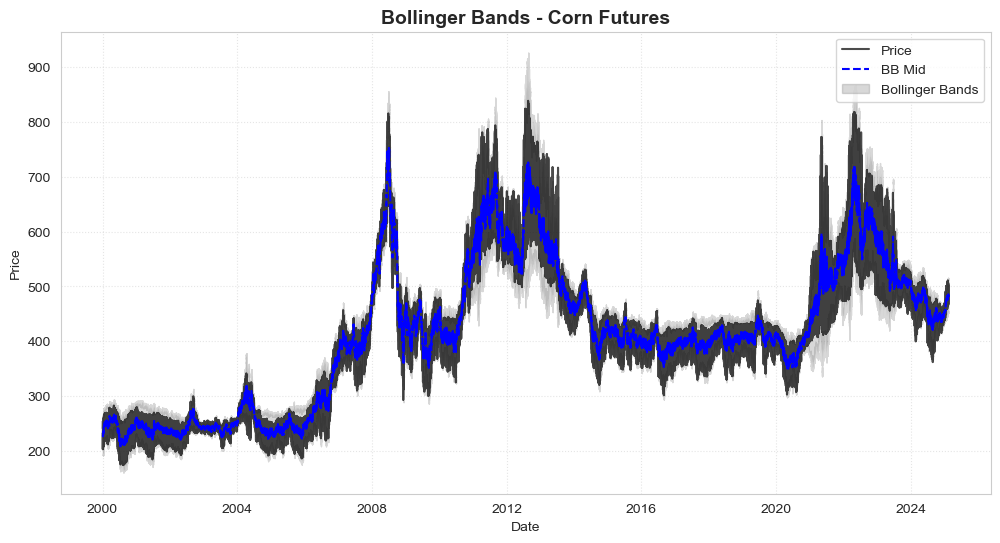

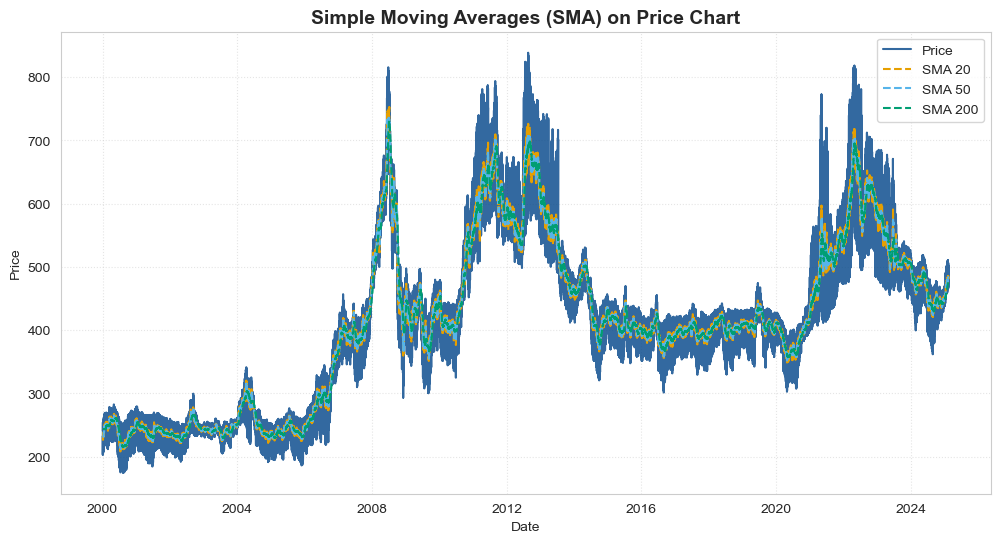

In [12]:
sns.set_style("whitegrid")  
sns.set_palette("muted")

plt.figure(figsize=(12, 6))
plt.plot(df_combined.index, df_combined["Price"], label="Price", color="#004488", alpha=0.8)
plt.plot(df_combined.index, df_combined["Fib_38.2"], label="Fib 38.2%", linestyle="dashed", color="#E69F00", linewidth=1.5)
plt.plot(df_combined.index, df_combined["Fib_50"], label="Fib 50%", linestyle="dashed", color="#56B4E9", linewidth=1.5)
plt.plot(df_combined.index, df_combined["Fib_61.8"], label="Fib 61.8%", linestyle="dashed", color="#009E73", linewidth=1.5)
plt.title("Corn Futures Price with Fibonacci Levels", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, linestyle="dotted", alpha=0.5)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df_combined.index, df_combined["MACD"], label="MACD Line", color="#0072B2", linewidth=1.5)
plt.plot(df_combined.index, df_combined["MACD_Signal"], label="MACD Signal", color="#D55E00", linestyle="dashed", linewidth=1.5)
plt.fill_between(df_combined.index, df_combined["MACD"] - df_combined["MACD_Signal"], where=(df_combined["MACD"] > df_combined["MACD_Signal"]), color="green", alpha=0.3)
plt.fill_between(df_combined.index, df_combined["MACD"] - df_combined["MACD_Signal"], where=(df_combined["MACD"] < df_combined["MACD_Signal"]), color="red", alpha=0.3)
plt.axhline(0, color="black", linewidth=0.5, linestyle="dotted")
plt.title("MACD Indicator", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("MACD Value")
plt.legend()
plt.grid(True, linestyle="dotted", alpha=0.5)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df_combined.index, df_combined["RSI"], label="RSI", color="#CC79A7", linewidth=1.5)
plt.axhline(70, linestyle="dashed", color="red", label="Overbought (70)")
plt.axhline(30, linestyle="dashed", color="green", label="Oversold (30)")
plt.fill_between(df_combined.index, 30, 70, color="gray", alpha=0.2)
plt.title("RSI Indicator", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("RSI Value")
plt.legend()
plt.grid(True, linestyle="dotted", alpha=0.5)
plt.show()


plt.figure(figsize=(12, 6))
plt.plot(df_combined.index, df_combined["Price"], label="Price", color="black", alpha=0.7)
plt.plot(df_combined.index, df_combined["BB_Middle"], label="BB Mid", linestyle="dashed", color="blue")
plt.fill_between(df_combined.index, df_combined["BB_Lower"], df_combined["BB_Upper"], color="gray", alpha=0.3, label="Bollinger Bands")
plt.title("Bollinger Bands - Corn Futures", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, linestyle="dotted", alpha=0.5)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df_combined.index, df_combined["Price"], label="Price", color="#004488", alpha=0.8)
plt.plot(df_combined.index, df_combined["SMA_20"], label="SMA 20", linestyle="dashed", color="#E69F00", linewidth=1.5)
plt.plot(df_combined.index, df_combined["SMA_50"], label="SMA 50", linestyle="dashed", color="#56B4E9", linewidth=1.5)
plt.plot(df_combined.index, df_combined["SMA_200"], label="SMA 200", linestyle="dashed", color="#009E73", linewidth=1.5)
plt.title("Simple Moving Averages (SMA) on Price Chart", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, linestyle="dotted", alpha=0.5)
plt.show()


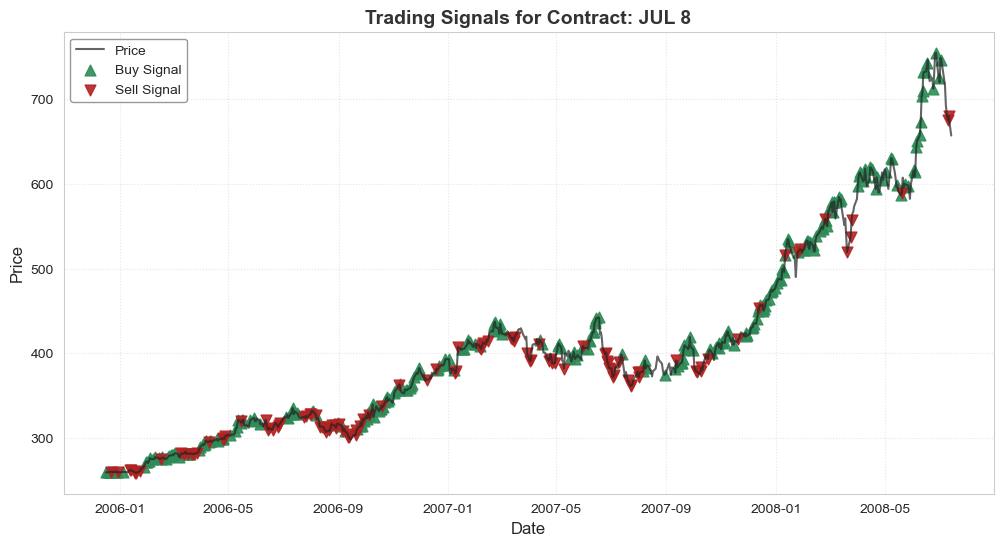

In [13]:
selected_contract = "jul 8" 

df_contract = df_combined[df_combined["Contract_Expiration"] == selected_contract]

plt.figure(figsize=(12, 6))

plt.plot(df_contract.index, df_contract["Price"], label="Price", color="#222222", linewidth=1.5, alpha=0.7)

plt.scatter(df_contract.index[df_contract["Buy_Signal"]], df_contract["Price"][df_contract["Buy_Signal"]], 
            label="Buy Signal", color="#2E8B57", marker="^", s=60, alpha=0.9)

plt.scatter(df_contract.index[df_contract["Sell_Signal"]], df_contract["Price"][df_contract["Sell_Signal"]], 
            label="Sell Signal", color="#B22222", marker="v", s=60, alpha=0.9)

plt.title(f"Trading Signals for Contract: {selected_contract.upper()}", fontsize=14, fontweight="bold", color="#333333")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price", fontsize=12)

plt.legend(frameon=True, facecolor="white", edgecolor="gray")
plt.grid(True, linestyle="dotted", alpha=0.5)

plt.show()


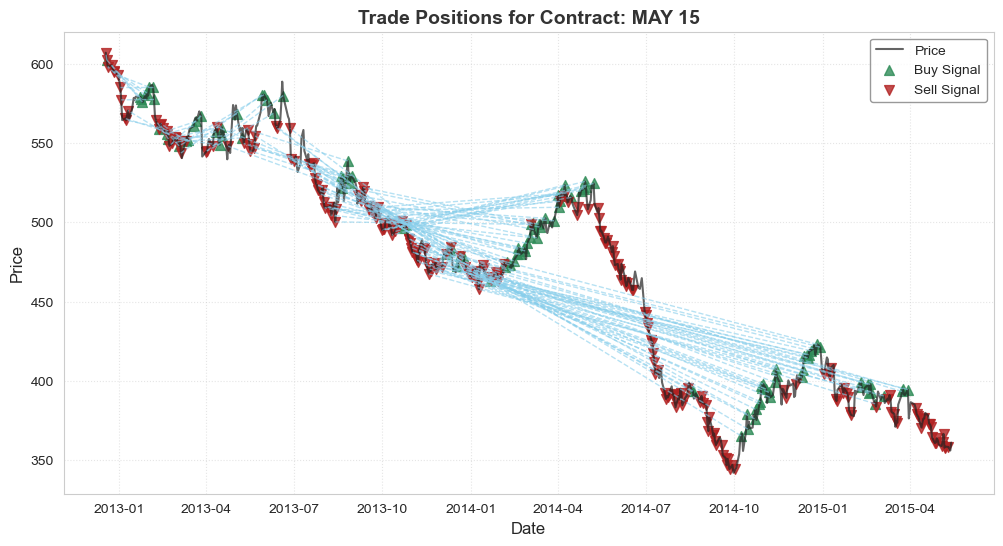

In [14]:
selected_contract = "may 15"  

df_contract = df_combined[df_combined["Contract_Expiration"] == selected_contract].copy()

buy_positions = df_contract[df_contract["Buy_Signal"]].copy()
sell_positions = df_contract[df_contract["Sell_Signal"]].copy()

buy_sell_pairs = []
open_positions = []  

for index, row in buy_positions.iterrows():
    open_positions.append((index, row["Price"])) 

for index, row in sell_positions.iterrows():
    if open_positions: 
        buy_index, buy_price = open_positions.pop(0) 
        buy_sell_pairs.append(((buy_index, buy_price), (index, row["Price"]))) 

plt.figure(figsize=(12, 6))

plt.plot(df_contract.index, df_contract["Price"], label="Price", color="#222222", linewidth=1.5, alpha=0.7)

plt.scatter(buy_positions.index, buy_positions["Price"], label="Buy Signal", color="#2E8B57", marker="^", s=50, alpha=0.8)

plt.scatter(sell_positions.index, sell_positions["Price"], label="Sell Signal", color="#B22222", marker="v", s=50, alpha=0.8)

for (buy_point, sell_point) in buy_sell_pairs:
    plt.plot([buy_point[0], sell_point[0]], [buy_point[1], sell_point[1]], 
             color="#87CEEB", linestyle="dashed", linewidth=1, alpha=0.6) 

plt.title(f"Trade Positions for Contract: {selected_contract.upper()}", fontsize=14, fontweight="bold", color="#333333")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price", fontsize=12)

plt.legend(frameon=True, facecolor="white", edgecolor="gray")
plt.grid(True, linestyle="dotted", alpha=0.5)

plt.show()


# ALGORITHM CREATION

## Data split

In [15]:
df_combined = df_combined.sort_index()

train_size = int(0.6 * len(df_combined)) 
val_size = int(0.2 * len(df_combined))
test_size = len(df_combined) - train_size - val_size 

train_data = df_combined.iloc[:train_size]  
val_data = df_combined.iloc[train_size:train_size + val_size]
test_data = df_combined.iloc[train_size + val_size:] 

print(f"Training Data Range: {train_data.index.min()} to {train_data.index.max()} ({train_data.shape[0]} rows)")
print(f"Validation Data Range: {val_data.index.min()} to {val_data.index.max()} ({val_data.shape[0]} rows)")
print(f"Test Data Range: {test_data.index.min()} to {test_data.index.max()} ({test_data.shape[0]} rows)")


Training Data Range: 2000-01-04 00:00:00 to 2015-11-24 00:00:00 (50389 rows)
Validation Data Range: 2015-11-24 00:00:00 to 2020-06-05 00:00:00 (16796 rows)
Test Data Range: 2020-06-05 00:00:00 to 2025-02-10 00:00:00 (16797 rows)


## Version 1 - Baseline Technical Model 

Validation Set Classification Report:
              precision    recall  f1-score   support

          -1       0.51      0.68      0.58      4697
           0       0.56      0.47      0.51      7445
           1       0.61      0.56      0.59      4654

    accuracy                           0.55     16796
   macro avg       0.56      0.57      0.56     16796
weighted avg       0.56      0.55      0.55     16796

Test Set Classification Report:
              precision    recall  f1-score   support

          -1       0.44      0.62      0.51      4138
           0       0.51      0.19      0.28      7554
           1       0.45      0.72      0.55      5105

    accuracy                           0.46     16797
   macro avg       0.47      0.51      0.45     16797
weighted avg       0.47      0.46      0.42     16797



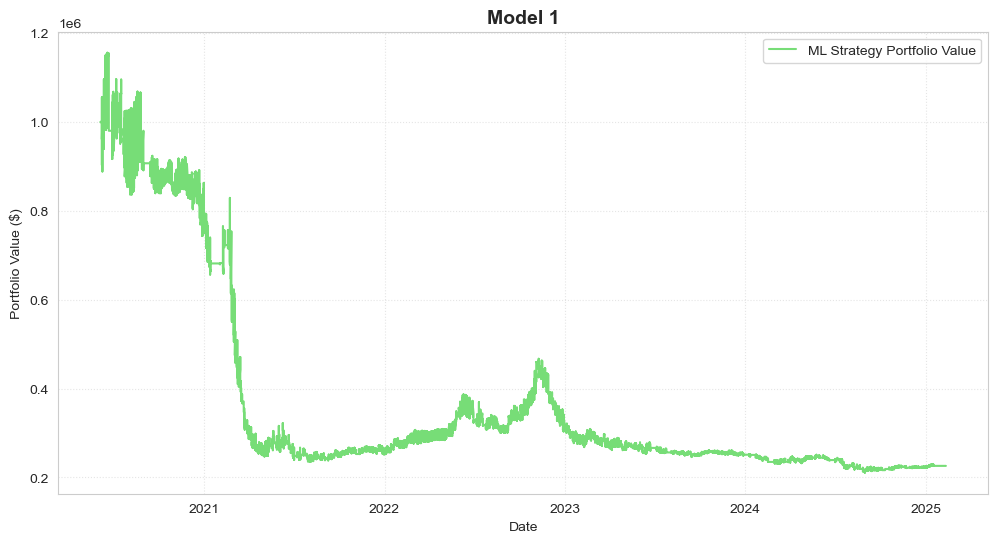

Initial Capital: $1,000,000.00
Final Portfolio Value: $226,000.00
Total Return: $-774,000.00
Return on Investment (ROI): -77.40%
Price          3.589994e+07
Buy_Signal     2.433900e+04
Sell_Signal    2.340100e+04
dtype: float64

Additional Performance Metrics:
Sharpe Ratio: 0.08
Max Drawdown: -81.78%
Profit Factor: 1.03
Win/Loss Ratio: 0.99


In [16]:
def backtest_strategy(df, initial_capital=1_000_000, contract_size=100, max_allocation=0.2):
   
    df = df.copy()
    
    cash = initial_capital
    position = 0
    investment = []
    portfolio_value = []
    roi = []

    for index, row in df.iterrows():
        price = row["Price"]
        max_contracts = (cash * max_allocation) // (price * contract_size)

        if row["Buy_Predicted"]:
            if max_contracts > 0:
                position += max_contracts
                cash -= max_contracts * price * contract_size

        elif row["Sell_Predicted"] and position > 0:
            cash += position * price * contract_size
            position = 0  

        invested = position * price * contract_size
        total_value = cash + invested
        investment.append(invested)
        portfolio_value.append(total_value)
        roi.append((total_value - initial_capital) / initial_capital * 100)

    df["Portfolio_Value"] = portfolio_value
    df["Investment"] = investment
    df["ROI (%)"] = roi

    return df

df_algo1 = compute_technical_indicators(df_combined.copy())
df_algo1 = classify_market_trend(df_algo1)
df_algo1 = detect_support_resistance(df_algo1)
df_algo1 = calculate_trading_score(df_algo1)
df_algo1 = generate_long_term_trading_signals(df_algo1)

train_data = train_data.copy()
val_data = val_data.copy()
test_data = test_data.copy()

train_data["Signal"] = np.where(train_data["Buy_Signal"], 1, np.where(train_data["Sell_Signal"], -1, 0))
val_data["Signal"] = np.where(val_data["Buy_Signal"], 1, np.where(val_data["Sell_Signal"], -1, 0))
test_data["Signal"] = np.where(test_data["Buy_Signal"], 1, np.where(test_data["Sell_Signal"], -1, 0))

features = ["SMA_20", "SMA_50", "SMA_200", "RSI", "MACD", "MACD_Signal", 
            "BB_Upper", "BB_Lower", "Fib_38.2", "Fib_50", "Fib_61.8", "Stochastic_%K"]

X_train, y_train = train_data[features], train_data["Signal"]
X_val, y_val = val_data[features], val_data["Signal"]
X_test, y_test = test_data[features], test_data["Signal"]

model1 = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight="balanced")
model1.fit(X_train, y_train)

y_pred_val = model1.predict(X_val)
y_pred_test = model1.predict(X_test)

print("Validation Set Classification Report:")
print(classification_report(y_val, y_pred_val))

print("Test Set Classification Report:")
print(classification_report(y_test, y_pred_test))

test_data["Predicted_Signal"] = model1.predict(X_test)
test_data["Buy_Predicted"] = test_data["Predicted_Signal"] == 1
test_data["Sell_Predicted"] = test_data["Predicted_Signal"] == -1

test_data = backtest_strategy(test_data)

plt.figure(figsize=(12, 6))
plt.plot(test_data.index, test_data["Portfolio_Value"], label="ML Strategy Portfolio Value", color="#77DD77")
plt.title("Model 1", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True, linestyle="dotted", alpha=0.5)
plt.show()

final_portfolio_value = test_data["Portfolio_Value"].iloc[-1]
initial_capital = 1_000_000 
total_return = final_portfolio_value - initial_capital  
roi_percentage = (total_return / initial_capital) * 100  

print(f"Initial Capital: ${initial_capital:,.2f}")
print(f"Final Portfolio Value: ${final_portfolio_value:,.2f}")
print(f"Total Return: ${total_return:,.2f}")
print(f"Return on Investment (ROI): {roi_percentage:.2f}%")

print(df_algo1[["Price", "Buy_Signal", "Sell_Signal"]].sum())

test_data["Daily_Return"] = test_data["Portfolio_Value"].pct_change()

risk_free_rate = 0.02
sharpe_ratio = (test_data["Daily_Return"].mean() - risk_free_rate/252) / test_data["Daily_Return"].std()
sharpe_ratio *= np.sqrt(252)

rolling_max = test_data["Portfolio_Value"].cummax()
drawdown = test_data["Portfolio_Value"] / rolling_max - 1
max_drawdown = drawdown.min() * 100

total_gains = test_data[test_data["Daily_Return"] > 0]["Daily_Return"].sum()
total_losses = abs(test_data[test_data["Daily_Return"] < 0]["Daily_Return"].sum())
profit_factor = total_gains / total_losses if total_losses > 0 else np.nan

num_winning_trades = (test_data["Daily_Return"] > 0).sum()
num_losing_trades = (test_data["Daily_Return"] < 0).sum()
win_loss_ratio = num_winning_trades / num_losing_trades if num_losing_trades > 0 else np.nan

print("\nAdditional Performance Metrics:")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Max Drawdown: {max_drawdown:.2f}%")
print(f"Profit Factor: {profit_factor:.2f}")
print(f"Win/Loss Ratio: {win_loss_ratio:.2f}")


## Version 2 - Weighted Score Model

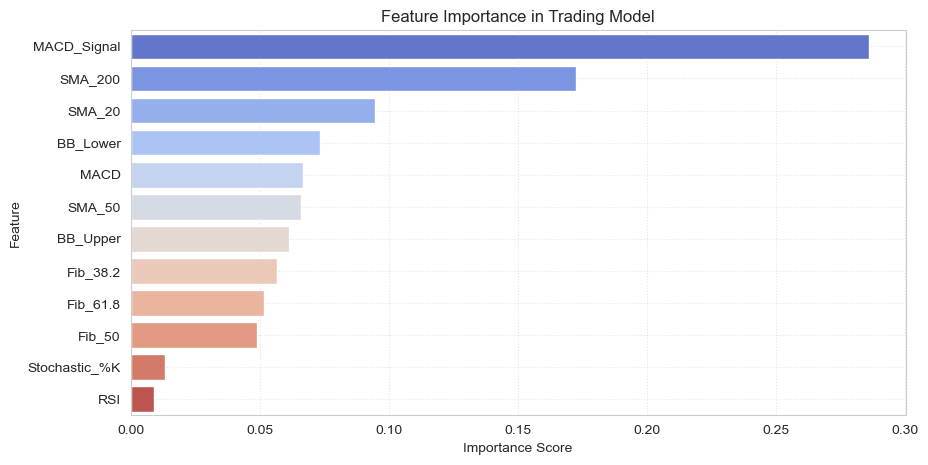

          Feature  Importance
5     MACD_Signal    0.285762
2         SMA_200    0.172472
0          SMA_20    0.094627
7        BB_Lower    0.073221
4            MACD    0.066767
1          SMA_50    0.066110
6        BB_Upper    0.061219
8        Fib_38.2    0.056896
10       Fib_61.8    0.051696
9          Fib_50    0.048826
11  Stochastic_%K    0.013501
3             RSI    0.008902


In [17]:
importances = model1.feature_importances_
feature_importance_df = pd.DataFrame({"Feature": features, "Importance": importances})
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df, palette="coolwarm")
plt.title("Feature Importance in Trading Model")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.grid(True, linestyle="dotted", alpha=0.5)
plt.show()

print(feature_importance_df)


In [18]:
df_algo2 = df_combined.copy()


Initial Capital: $1,000,000.00
Final Portfolio Value: $1,292,200.00
Total Return: $292,200.00
Return on Investment (ROI): 29.22%
Validation Set Classification Report (Optimized Model):
              precision    recall  f1-score   support

          -1       0.55      0.47      0.51      3743
           0       0.55      0.59      0.57      6715
           1       0.60      0.61      0.61      4652

    accuracy                           0.57     15110
   macro avg       0.57      0.56      0.56     15110
weighted avg       0.57      0.57      0.56     15110

Test Set Classification Report (Optimized Model):
              precision    recall  f1-score   support

          -1       0.58      0.59      0.59      2282
           0       0.57      0.48      0.52      3264
           1       0.54      0.69      0.60      1674

    accuracy                           0.56      7220
   macro avg       0.56      0.59      0.57      7220
weighted avg       0.57      0.56      0.56      7220



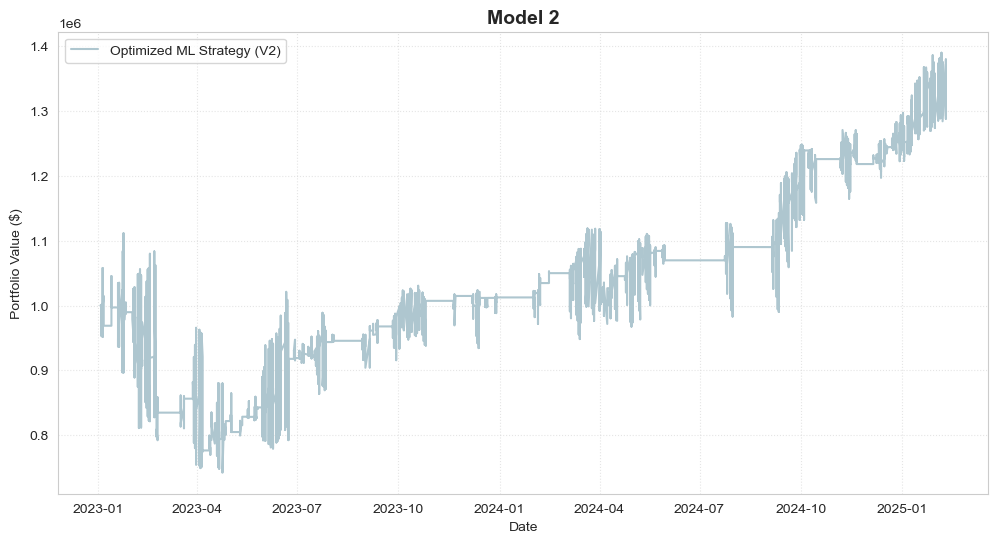


Optimized ML Trading Strategy - Performance Metrics:
Sharpe Ratio: 0.21
Maximubbm Drawdown: -33.23%
Profit Factor: 1.08
Win/Loss Ratio: 1.0


In [19]:
def calculate_optimized_trading_score(df):

    weights = {
        "MACD_Signal": 0.3, 
        "SMA_200": 0.2,  
        "SMA_20": 0.15,  
        "BB_Lower": 0.1,  
        "MACD": 0.07,  
        "SMA_50": 0.06,  
        "BB_Upper": 0.06,  
        "Fib_38.2": 0.05,  
        "Fib_61.8": 0.05,  
        "Fib_50": 0.04,  
        "Stochastic_%K": 0.02,  
        "RSI": 0.01 
    }

    df["Technical_Score"] = (
        df["MACD_Signal"] * weights["MACD_Signal"] +
        df["SMA_200"] * weights["SMA_200"] +
        df["SMA_20"] * weights["SMA_20"] +
        df["BB_Lower"] * weights["BB_Lower"] +
        df["MACD"] * weights["MACD"] +
        df["SMA_50"] * weights["SMA_50"] +
        df["BB_Upper"] * weights["BB_Upper"] +
        df["Fib_38.2"] * weights["Fib_38.2"] +
        df["Fib_61.8"] * weights["Fib_61.8"] +
        df["Fib_50"] * weights["Fib_50"] +
        df["Stochastic_%K"] * weights["Stochastic_%K"] +
        df["RSI"] * weights["RSI"]
    )

    buy_threshold = 0.55 
    sell_threshold = -0.55

    df["Buy_Signal"] = df["Technical_Score"] >= buy_threshold
    df["Sell_Signal"] = df["Technical_Score"] <= sell_threshold

    return df

train_data = df_algo2[df_algo2.index < "2019-01-01"]
val_data = df_algo2[(df_algo2.index >= "2019-01-01") & (df_algo2.index < "2023-01-01")]
test_data = df_algo2[df_algo2.index >= "2023-01-01"]

df_algo2 = calculate_optimized_trading_score(df_algo2)

def backtest_with_risk_management(df, initial_capital=1_000_000, contract_size=100, max_allocation=0.2):
    """
    Improved backtesting function:
    - Limits position sizing to max_allocation of capital.
    - Includes stop-loss & take-profit logic.
    - Prevents overtrading by enforcing a minimum holding period.
    """
    df = df.copy()
    
    cash = initial_capital
    position = 0
    investment = []
    portfolio_value = []
    roi = []
    min_holding_days = 5 

    holding_counter = 0 

    for index, row in df.iterrows():
        price = row["Price"]
        max_contracts = (cash * max_allocation) // (price * contract_size)

        if row["Buy_Signal"] and holding_counter >= min_holding_days:
            if max_contracts > 0:
                position += max_contracts
                cash -= max_contracts * price * contract_size
                holding_counter = 0 

        elif row["Sell_Signal"] and position > 0 and holding_counter >= min_holding_days:
            cash += position * price * contract_size
            position = 0
            holding_counter = 0

        invested = position * price * contract_size
        total_value = cash + invested
        investment.append(invested)
        portfolio_value.append(total_value)
        roi.append((total_value - initial_capital) / initial_capital * 100)

        holding_counter += 1

    df["Portfolio_Value"] = portfolio_value
    df["Investment"] = investment
    df["ROI (%)"] = roi

    return df
test_data_algo2 = backtest_with_risk_management(test_data.copy())

final_portfolio_value = test_data_algo2["Portfolio_Value"].iloc[-1] 
initial_capital = 1_000_000  
total_return = final_portfolio_value - initial_capital 
roi_percentage = (total_return / initial_capital) * 100 

print(f"Initial Capital: ${initial_capital:,.2f}")
print(f"Final Portfolio Value: ${final_portfolio_value:,.2f}")
print(f"Total Return: ${total_return:,.2f}")
print(f"Return on Investment (ROI): {roi_percentage:.2f}%")

train_data = train_data.copy()
val_data = val_data.copy()
test_data = test_data.copy()

train_data["Signal"] = np.where(train_data["Buy_Signal"], 1, 
                                np.where(train_data["Sell_Signal"], -1, 0))
val_data["Signal"] = np.where(val_data["Buy_Signal"], 1, 
                              np.where(val_data["Sell_Signal"], -1, 0))
test_data["Signal"] = np.where(test_data["Buy_Signal"], 1, 
                               np.where(test_data["Sell_Signal"], -1, 0))

features = ["MACD_Signal", "SMA_200", "SMA_20", "BB_Lower", "MACD", 
            "SMA_50", "BB_Upper", "Fib_38.2", "Fib_61.8", "Fib_50", 
            "Stochastic_%K", "RSI"]
X_train, y_train = train_data[features], train_data["Signal"]
X_val, y_val = val_data[features], val_data["Signal"]
X_test, y_test = test_data[features], test_data["Signal"]

model_v2 = RandomForestClassifier(n_estimators=300, max_depth=15, 
                                  min_samples_split=5, min_samples_leaf=2,
                                  random_state=42, class_weight="balanced")
model_v2.fit(X_train, y_train)

y_pred_val = model_v2.predict(X_val)
y_pred_test = model_v2.predict(X_test)

print("Validation Set Classification Report (Optimized Model):")
print(classification_report(y_val, y_pred_val))

print("Test Set Classification Report (Optimized Model):")
print(classification_report(y_test, y_pred_test))

test_data["Predicted_Signal"] = model_v2.predict(X_test)
test_data["Buy_Predicted"] = test_data["Predicted_Signal"] == 1
test_data["Sell_Predicted"] = test_data["Predicted_Signal"] == -1

test_data = backtest_with_risk_management(test_data)

plt.figure(figsize=(12, 6))
plt.plot(test_data.index, test_data["Portfolio_Value"], label="Optimized ML Strategy (V2)", color="#AEC6CF")
plt.title("Model 2", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True, linestyle="dotted", alpha=0.5)
plt.show()

import numpy as np

def calculate_performance_metrics(df, risk_free_rate=0.02):

    df["Daily_Return"] = df["Portfolio_Value"].pct_change()

    sharpe_ratio = (df["Daily_Return"].mean() - risk_free_rate / 252) / df["Daily_Return"].std()
    sharpe_ratio *= np.sqrt(252)  

    rolling_max = df["Portfolio_Value"].cummax()
    drawdown = df["Portfolio_Value"] / rolling_max - 1
    max_drawdown = drawdown.min() * 100  

    total_gains = df[df["Daily_Return"] > 0]["Daily_Return"].sum()
    total_losses = abs(df[df["Daily_Return"] < 0]["Daily_Return"].sum())
    profit_factor = total_gains / total_losses if total_losses > 0 else np.nan  

    num_winning_trades = (df["Daily_Return"] > 0).sum()
    num_losing_trades = (df["Daily_Return"] < 0).sum()
    win_loss_ratio = num_winning_trades / num_losing_trades if num_losing_trades > 0 else np.nan  # Avoid division by zero

    return {
        "Sharpe Ratio": round(sharpe_ratio, 2),
        "Max Drawdown (%)": round(max_drawdown, 2),
        "Profit Factor": round(profit_factor, 2),
        "Win/Loss Ratio": round(win_loss_ratio, 2)
    }

performance_metrics = calculate_performance_metrics(test_data)

print("\nOptimized ML Trading Strategy - Performance Metrics:")
print(f"Sharpe Ratio: {performance_metrics['Sharpe Ratio']}")
print(f"Maximubbm Drawdown: {performance_metrics['Max Drawdown (%)']}%")
print(f"Profit Factor: {performance_metrics['Profit Factor']}")
print(f"Win/Loss Ratio: {performance_metrics['Win/Loss Ratio']}")




## Introducing external data

### Uploading weather data

In [20]:
import requests
import pandas as pd
import time

countries = {
    "United States": {"lat": 40.0, "lon": -95.0},
    "China": {"lat": 35.0, "lon": 103.0},
    "Brazil": {"lat": -15.0, "lon": -47.0},
    "European Union": {"lat": 48.0, "lon": 10.0},
    "Argentina": {"lat": -34.0, "lon": -64.0}
}

start_date = "2000-01-01"
end_date = "2025-01-01"

def fetch_weather_data(lat, lon, start, end):
    url = f"https://archive-api.open-meteo.com/v1/archive?latitude={lat}&longitude={lon}&start_date={start}&end_date={end}&daily=temperature_2m_max,temperature_2m_min,precipitation_sum&timezone=auto"
    response = requests.get(url)
    if response.status_code == 429:
        print("Rate limit hit. Waiting 10 seconds before retrying...")
        time.sleep(10)
        return fetch_weather_data(lat, lon, start, end)
    response.raise_for_status()
    data = response.json()
    df = pd.DataFrame(data["daily"])
    df["date"] = pd.to_datetime(df["time"])
    df = df.drop(columns=["time"])
    return df

weather_data = {}

for country, info in countries.items():
    try:
        print(f"Fetching data for {country}...")
        df = fetch_weather_data(info["lat"], info["lon"], start_date, end_date)
        weather_data[country] = df
        print(f"Data for {country} retrieved. Rows: {len(df)}")
        time.sleep(3) 
    except Exception as e:
        print(f"Error fetching data for {country}: {e}")


Fetching data for United States...
Data for United States retrieved. Rows: 9133
Fetching data for China...
Data for China retrieved. Rows: 9133
Fetching data for Brazil...
Data for Brazil retrieved. Rows: 9133
Fetching data for European Union...
Data for European Union retrieved. Rows: 9133
Fetching data for Argentina...
Rate limit hit. Waiting 10 seconds before retrying...
Rate limit hit. Waiting 10 seconds before retrying...
Rate limit hit. Waiting 10 seconds before retrying...
Rate limit hit. Waiting 10 seconds before retrying...
Rate limit hit. Waiting 10 seconds before retrying...
Data for Argentina retrieved. Rows: 9133


In [21]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

weights = {
    "United States": 0.32,
    "China": 0.23,
    "Brazil": 0.10,
    "European Union": 0.05,
    "Argentina": 0.04
}

def process_weather_data(weather_data_dict):
    """
    Normalize and weight weather features by each country’s corn production share.
    Returns a DataFrame with a Global_Weather_Impact_Score.
    """
    impact_df = None
    scaler = MinMaxScaler()

    for country, df in weather_data_dict.items():
        df = df.copy()
        df["date"] = pd.to_datetime(df["date"])
        df.set_index("date", inplace=True)
        
        features = ["precipitation_sum", "temperature_2m_max", "temperature_2m_min"]
        df[features] = scaler.fit_transform(df[features])
        
        for feature in features:
            df[f"{feature}_{country}"] = df[feature] * weights[country]

        df = df[[f"{feature}_{country}" for feature in features]]
        
        if impact_df is None:
            impact_df = df
        else:
            impact_df = impact_df.join(df, how="outer")

    impact_df["Global_Weather_Impact_Score"] = impact_df.sum(axis=1)
    impact_df.reset_index(inplace=True)
    
    return impact_df[["date", "Global_Weather_Impact_Score"]]

global_weather_score_df = process_weather_data(weather_data)
print(global_weather_score_df.head())


        date  Global_Weather_Impact_Score
0 2000-01-01                     0.752116
1 2000-01-02                     0.734636
2 2000-01-03                     0.683047
3 2000-01-04                     0.628157
4 2000-01-05                     0.715711


In [22]:
df_combined = df_combined.reset_index()

df_combined["Date"] = pd.to_datetime(df_combined["Date"])
global_weather_score_df["date"] = pd.to_datetime(global_weather_score_df["date"])

df_combined = df_combined.merge(global_weather_score_df, left_on="Date", right_on="date", how="left")

df_combined.drop(columns=["date"], inplace=True)
df_combined["Global_Weather_Impact_Score"] = df_combined["Global_Weather_Impact_Score"].fillna(method="ffill")

print("Weather impact score successfully merged into df_combined!")


Weather impact score successfully merged into df_combined!


In [23]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
for country, df in weather_data.items():
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])

    for col in ["precipitation_sum", "temperature_2m_max", "temperature_2m_min"]:
        df[[col]] = scaler.fit_transform(df[[col]])

    df["impact"] = (
        0.5 * df["precipitation_sum"] +
        0.25 * df["temperature_2m_max"] +
        0.25 * df["temperature_2m_min"]
    )

    weather_data[country] = df


In [24]:
seasonal_weights = {
    "United States": {5: 1.0, 6: 1.0, 7: 1.0, 8: 1.0},
    "Brazil": {1: 1.0, 2: 1.0, 3: 1.0},
    "China": {5: 0.9, 6: 0.9, 7: 0.9, 8: 0.9},
    "Argentina": {12: 1.0, 1: 1.0, 2: 1.0},
    "European Union": {4: 0.8, 5: 0.8, 6: 0.8, 7: 0.8},
}

production_weights = {
    "United States": 0.32,
    "China": 0.23,
    "Brazil": 0.10,
    "European Union": 0.05,
    "Argentina": 0.04
}

def compute_seasonal_weather_score(weather_data, production_weights, seasonal_weights):
    all_dates = pd.date_range(start="2000-01-01", end="2025-01-01", freq="D")
    final_df = pd.DataFrame({"Date": all_dates})
    final_df["Seasonal_Weather_Impact_Score"] = 0.0

    for country, df in weather_data.items():
        df = df.copy()
        df["date"] = pd.to_datetime(df["date"])
        df["month"] = df["date"].dt.month
        df["seasonal_weight"] = df["month"].apply(lambda m: seasonal_weights.get(country, {}).get(m, 0.3))
        df["weighted_impact"] = df["impact"] * df["seasonal_weight"] * production_weights[country]
        df = df[["date", "weighted_impact"]].rename(columns={"date": "Date"})
        final_df = final_df.merge(df, on="Date", how="left")
        final_df["Seasonal_Weather_Impact_Score"] += final_df["weighted_impact"].fillna(0)
        final_df.drop(columns=["weighted_impact"], inplace=True)

    return final_df

seasonal_weather_df = compute_seasonal_weather_score(weather_data, production_weights, seasonal_weights)


### Uploading news data

In [25]:
df_2000_2017 = pd.read_csv("/Users/carlotagomezmontes/Desktop/5th 2nd /FT DATA/Algorithm/corn_market_news_google_reuters_2000_2024.csv")
df_2018_2025 = pd.read_csv("/Users/carlotagomezmontes/Desktop/5th 2nd /FT DATA/Algorithm/corn_market_news_google_reuters_2018_2025.csv")

df_news = pd.concat([df_2000_2017, df_2018_2025], ignore_index=True)

df_news.drop_duplicates(subset=["Title"], inplace=True)
df_news = df_news[df_news["Year"].notna()]
df_news["Year"] = df_news["Year"].astype(int)

df_news = df_news[["Year", "Title", "Snippet", "Media", "Link"]]

df_news = df_news.sort_values("Year").reset_index(drop=True)

df_news.to_csv("corn_market_news_cleaned_by_year.csv", index=False)

print(f"Combined dataset has {len(df_news)} unique headlines from {df_news['Year'].min()} to {df_news['Year'].max()}")
print(df_news.head(10))


Combined dataset has 38 unique headlines from 2000 to 2018
   Year                                              Title  \
0  2000  Argentine peso slides after FX controls eased,...   
1  2000  Chilean miner Codelco logging strong Q2 demand...   
2  2000  Thailand will cut tariffs on US corn imports, ...   
3  2000   Mercedes to end engagement in small vans segment   
4  2000  CBOT corn rally more than justified by US supp...   
5  2000  ECB ready to deploy its instruments to maintai...   
6  2000                     Take Five: Riders on the storm   
7  2000  From Daikin to Samsung, companies fight Modi o...   
8  2000  Argentine workers launch widespread 24-hour st...   
9  2000       US consumer inflation eases ahead of tariffs   

                                             Snippet    Media  \
0  The Argentine peso slid around 9% on Monday mo...  Reuters   
1  Chilean copper giant Codelco is seeing strong ...  Reuters   
2  Thailand will cut tariffs on imports of corn f...  Reuters  

In [26]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import pandas as pd

analyzer = SentimentIntensityAnalyzer()

df_news["Sentiment"] = df_news["Title"].apply(lambda x: analyzer.polarity_scores(str(x))["compound"])


In [27]:
yearly_sentiment = df_news.groupby("Year")["Sentiment"].mean().reset_index()
yearly_sentiment.columns = ["Year", "Average_Sentiment"]


In [28]:
df_sentiment = df_combined.copy()

df_sentiment["Year"] = pd.to_datetime(df_sentiment["Date"]).dt.year

df_sentiment = df_sentiment.merge(yearly_sentiment, on="Year", how="left")

df_sentiment["Average_Sentiment"] = df_sentiment["Average_Sentiment"].fillna(method="ffill").fillna(method="bfill")


In [29]:
df_sentiment["Date"] = pd.to_datetime(df_sentiment["Date"])
seasonal_weather_df["Date"] = pd.to_datetime(seasonal_weather_df["Date"])

df_sentiment = df_sentiment.merge(seasonal_weather_df, on="Date", how="left")

df_sentiment["Seasonal_Weather_Impact_Score"] = df_sentiment["Seasonal_Weather_Impact_Score"].fillna(method="ffill").fillna(method="bfill")


## Version 3 - Hybrid Ensemble Model

/Users/carlotagomezmontes/anaconda3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [18:39:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004056 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3825
[LightGBM] [Info] Number of data points in the train set: 46791, number of used features: 15
[LightGBM] [Info] Start training from score -0.841445
[LightGBM] [Info] Start training from score -1.994877
[LightGBM] [Info] Start training from score -0.837289
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
🧪 Validation Classification Report:
              precision    recall  f1-score   support

          -1       0.65      0.74      0.69      7882
           0       0.33      0.00      0.00      2680
           1       0.69      0.83      0.75      7872

    accuracy                           0.67     18434
   macro avg       0.56      0.52      0.48     18434
weighted avg       0.62      0.67    

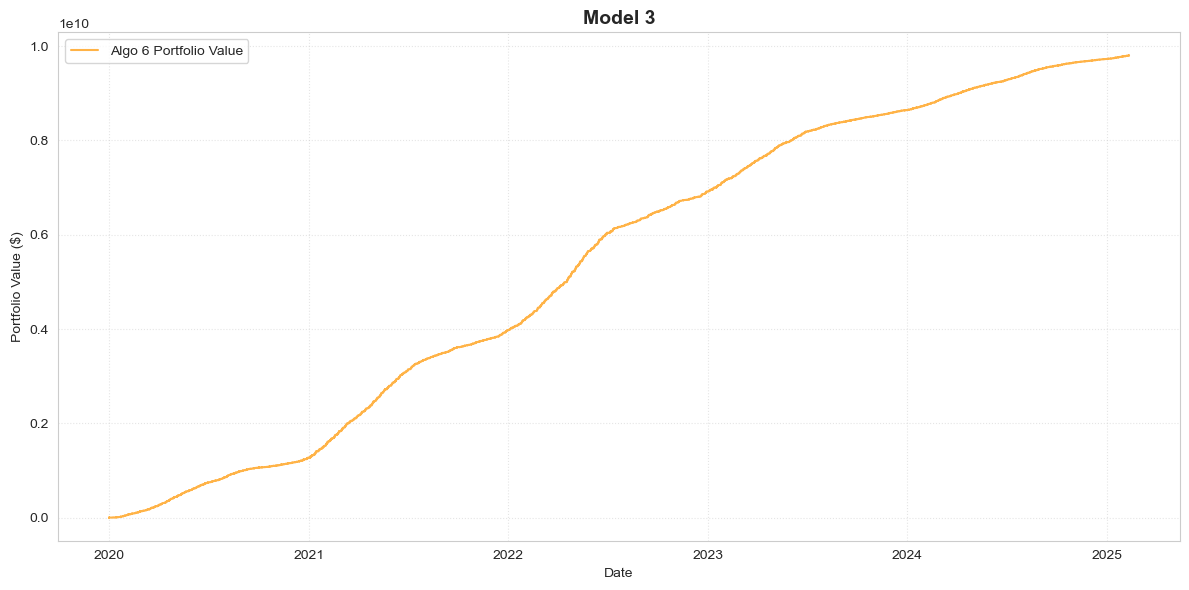

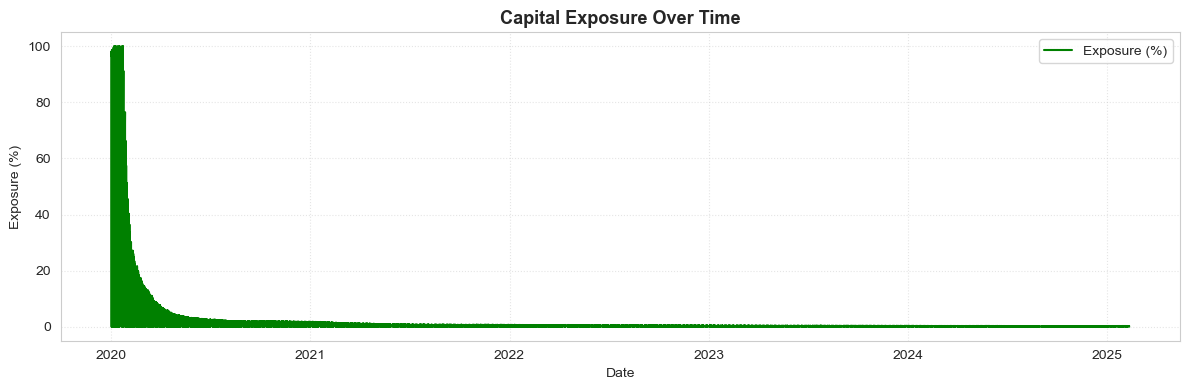


Average Exposure: 1.17%

Capital Overview:
Initial Capital: $1,000,000.00
Final Portfolio Value: $9,800,273,125.00
Total Return: $9,799,273,125.00
Return on Investment (ROI): 979927.31%


In [30]:
import pandas as pd
import numpy as np

def prepare_features(df):
    df = df.copy()
    df["SMA_20"] = df["Price"].rolling(20).mean()
    df["SMA_50"] = df["Price"].rolling(50).mean()
    df["SMA_200"] = df["Price"].rolling(200).mean()

    df["RSI"] = compute_rsi(df["Price"], window=14)
    df["MACD"] = df["Price"].ewm(span=12, adjust=False).mean() - df["Price"].ewm(span=26, adjust=False).mean()
    df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()
    df["Stochastic_%K"] = (df["Price"] - df["Price"].rolling(14).min()) / (df["Price"].rolling(14).max() - df["Price"].rolling(14).min())
    
    df["BB_Upper"] = df["Price"].rolling(20).mean() + 2 * df["Price"].rolling(20).std()
    df["BB_Lower"] = df["Price"].rolling(20).mean() - 2 * df["Price"].rolling(20).std()
    
    high = df["Price"].rolling(50).max()
    low = df["Price"].rolling(50).min()
    df["Fib_38.2"] = high - (high - low) * 0.382
    df["Fib_50"] = high - (high - low) * 0.5
    df["Fib_61.8"] = high - (high - low) * 0.618

    df["ATR"] = df["Price"].rolling(14).std()

    return df

def compute_rsi(series, window):
    delta = series.diff()
    gain = np.where(delta > 0, delta, 0)
    loss = np.where(delta < 0, -delta, 0)
    avg_gain = pd.Series(gain).rolling(window=window).mean()
    avg_loss = pd.Series(loss).rolling(window=window).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

def label_data(df):
    df = df.copy()
    df["Future_Price"] = df["Price"].shift(-5)
    df["Return"] = (df["Future_Price"] - df["Price"]) / df["Price"]

    df["Signal"] = np.where(df["Return"] > 0.01, 1,
                            np.where(df["Return"] < -0.01, -1, 0))
    return df.drop(columns=["Future_Price", "Return"])

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import train_test_split

def train_ensemble_model(df):
    features = ["SMA_20", "SMA_50", "SMA_200", "RSI", "MACD", "MACD_Signal",
                "BB_Upper", "BB_Lower", "Fib_38.2", "Fib_50", "Fib_61.8",
                "Stochastic_%K", "Global_Weather_Impact_Score",
                "Seasonal_Weather_Impact_Score", "Average_Sentiment", "ATR"]
    
    df = df.dropna()
    X = df[features]
    y = df["Signal"]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

    rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
    xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, use_label_encoder=False, eval_metric='mlogloss')
    lgbm = LGBMClassifier(n_estimators=200, max_depth=7)

    ensemble = VotingClassifier(
        estimators=[("rf", rf), ("xgb", xgb), ("lgbm", lgbm)],
        voting="soft"
    )

    ensemble.fit(X_train, y_train)
    return ensemble, X_test, y_test

def backtest(df, model, initial_capital=1_000_000, contract_size=100, min_holding_days=5):
    df = df.copy()
    features = ["SMA_20", "SMA_50", "SMA_200", "RSI", "MACD", "MACD_Signal",
                "BB_Upper", "BB_Lower", "Fib_38.2", "Fib_50", "Fib_61.8",
                "Stochastic_%K", "Global_Weather_Impact_Score",
                "Seasonal_Weather_Impact_Score", "Average_Sentiment", "ATR"]
    df = df.dropna()

    X = df[features]
    pred_probs = model.predict_proba(X)
    confidence = pred_probs.max(axis=1)
    predicted = model.predict(X)
    
    df["Signal"] = predicted
    df["Confidence"] = confidence

    cash = initial_capital
    position = 0
    entry_price = 0
    holding_days = 0
    portfolio_value = []
    exposure_pct = []  


    for i, row in df.iterrows():
        price = row["Price"]
        atr = row["ATR"]
        signal = row["Signal"]
        conf = row["Confidence"]

        if pd.isna(price) or price <= 0 or pd.isna(atr) or np.isinf(price):
            portfolio_value.append(cash + position * entry_price * contract_size if position > 0 else cash)
            continue

        max_contracts = cash // (price * contract_size)

        max_contracts = min(max_contracts, 500) 

        if position > 0:
            holding_days += 1
            tp = entry_price * 1.05
            sl = entry_price * 0.95

            if price >= tp or price <= sl or signal == -1:
                cash += position * price * contract_size
                position = 0
                holding_days = 0

        if signal == 1 and conf > 0.6 and position == 0:
            if max_contracts > 0:
                position = max_contracts
                entry_price = price
                cash -= position * price * contract_size
                holding_days = 0

        current_value = cash + position * price * contract_size
        exposure = (position * price * contract_size) / current_value if current_value > 0 else 0
        portfolio_value.append(current_value)
        exposure_pct.append(exposure * 100) 


    df["Portfolio_Value"] = portfolio_value
    df["Exposure (%)"] = exposure_pct

    return df

def evaluate_performance(df):
    df["Daily_Return"] = df["Portfolio_Value"].pct_change()
    sharpe_ratio = (df["Daily_Return"].mean() / df["Daily_Return"].std()) * np.sqrt(252)

    max_drawdown = ((df["Portfolio_Value"] / df["Portfolio_Value"].cummax()) - 1).min() * 100
    total_return = df["Portfolio_Value"].iloc[-1] - df["Portfolio_Value"].iloc[0]
    roi = total_return / df["Portfolio_Value"].iloc[0] * 100

    gains = df[df["Daily_Return"] > 0]["Daily_Return"].sum()
    losses = -df[df["Daily_Return"] < 0]["Daily_Return"].sum()
    profit_factor = gains / losses if losses != 0 else np.nan

    win_trades = (df["Daily_Return"] > 0).sum()
    loss_trades = (df["Daily_Return"] < 0).sum()
    win_loss_ratio = win_trades / loss_trades if loss_trades > 0 else np.nan

    return {
        "Sharpe Ratio": round(sharpe_ratio, 2),
        "Max Drawdown (%)": round(max_drawdown, 2),
        "Total Return ($)": round(total_return, 2),
        "ROI (%)": round(roi, 2),
        "Profit Factor": round(profit_factor, 2),
        "Win/Loss Ratio": round(win_loss_ratio, 2)
    }

from sklearn.metrics import classification_report
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
import pandas as pd

df_sentiment_algo3 = df_sentiment.copy()
df_features3 = prepare_features(df_sentiment_algo3)
df_labeled3 = label_data(df_features3)

df_labeled3["Date"] = pd.to_datetime(df_labeled3["Date"])
train_df3 = df_labeled3[df_labeled3["Date"].dt.year <= 2014]
val_df3   = df_labeled3[(df_labeled3["Date"].dt.year >= 2015) & (df_labeled3["Date"].dt.year <= 2019)]
test_df3  = df_labeled3[df_labeled3["Date"].dt.year >= 2020]

features = ["SMA_20", "SMA_50", "SMA_200", "RSI", "MACD", "MACD_Signal",
            "BB_Upper", "BB_Lower", "Fib_38.2", "Fib_50", "Fib_61.8",
            "Stochastic_%K", "Global_Weather_Impact_Score",
            "Seasonal_Weather_Impact_Score", "Average_Sentiment", "ATR"]

train_df3 = train_df3.dropna()
val_df3   = val_df3.dropna()
test_df3  = test_df3.dropna()

X_train3, y_train3 = train_df3[features], train_df3["Signal"]
X_val3, y_val3     = val_df3[features], val_df3["Signal"]
X_test3, y_test3   = test_df3[features], test_df3["Signal"]

rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                    use_label_encoder=False, eval_metric='mlogloss')
lgbm = LGBMClassifier(n_estimators=200, max_depth=7)

ensemble_model = VotingClassifier(
    estimators=[("rf", rf), ("xgb", xgb), ("lgbm", lgbm)],
    voting="soft"
)
ensemble_model.fit(X_train3, y_train3)

y_pred_val3  = ensemble_model.predict(X_val3)
y_pred_test3 = ensemble_model.predict(X_test3)

print("🧪 Validation Classification Report:")
print(classification_report(y_val3, y_pred_val3))

print("\n📊 Test Classification Report:")
print(classification_report(y_test3, y_pred_test3))

test_df3 = test_df3.dropna()
df_backtest3 = backtest(test_df3, ensemble_model)

df_backtest3 = df_backtest3[np.isfinite(df_backtest3["Portfolio_Value"])]
df_backtest3 = df_backtest3[df_backtest3["Portfolio_Value"] > 0]

metrics = evaluate_performance(df_backtest3)

print("\nALGO 6 PERFORMANCE METRICS:")
for k, v in metrics.items():
    print(f"{k}: {v}")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df_backtest3["Date"], df_backtest3["Portfolio_Value"], label="Algo 6 Portfolio Value", color="#FFB347")
plt.title("Model 3", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True, linestyle="dotted", alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(df_backtest3["Date"], df_backtest3["Exposure (%)"], label="Exposure (%)", color="green")
plt.title("Capital Exposure Over Time", fontsize=13, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Exposure (%)")
plt.grid(True, linestyle="dotted", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nAverage Exposure: {df_backtest3['Exposure (%)'].mean():.2f}%")

initial_capital = 1_000_000
final_portfolio_value = df_backtest3["Portfolio_Value"].iloc[-1]
total_return = final_portfolio_value - initial_capital
roi_percentage = (total_return / initial_capital) * 100

print("\nCapital Overview:")
print(f"Initial Capital: ${initial_capital:,.2f}")
print(f"Final Portfolio Value: ${final_portfolio_value:,.2f}")
print(f"Total Return: ${total_return:,.2f}")
print(f"Return on Investment (ROI): {roi_percentage:.2f}%")



## Version 4 - Weather-Adjusted Strategy

In [31]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

def prepare_features(df):
    df = df.copy()
    df["SMA_20"] = df["Price"].rolling(20).mean()
    df["SMA_50"] = df["Price"].rolling(50).mean()
    df["SMA_200"] = df["Price"].rolling(200).mean()

    df["RSI"] = compute_rsi(df["Price"], window=14)
    df["MACD"] = df["Price"].ewm(span=12, adjust=False).mean() - df["Price"].ewm(span=26, adjust=False).mean()
    df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()
    df["Stochastic_%K"] = (df["Price"] - df["Price"].rolling(14).min()) / (df["Price"].rolling(14).max() - df["Price"].rolling(14).min())

    df["BB_Upper"] = df["Price"].rolling(20).mean() + 2 * df["Price"].rolling(20).std()
    df["BB_Lower"] = df["Price"].rolling(20).mean() - 2 * df["Price"].rolling(20).std()

    high = df["Price"].rolling(50).max()
    low = df["Price"].rolling(50).min()
    df["Fib_38.2"] = high - (high - low) * 0.382
    df["Fib_50"] = high - (high - low) * 0.5
    df["Fib_61.8"] = high - (high - low) * 0.618

    df["ATR"] = df["Price"].rolling(14).std()
    return df

def compute_rsi(series, window):
    delta = series.diff()
    gain = np.where(delta > 0, delta, 0)
    loss = np.where(delta < 0, -delta, 0)
    avg_gain = pd.Series(gain).rolling(window=window).mean()
    avg_loss = pd.Series(loss).rolling(window=window).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

def label_data(df):
    df = df.copy()
    df["Future_Price"] = df["Price"].shift(-5)
    df["Return"] = (df["Future_Price"] - df["Price"]) / df["Price"]
    df["Signal"] = np.where(df["Return"] > 0.01, 1, np.where(df["Return"] < -0.01, -1, 0))
    return df.drop(columns=["Future_Price", "Return"])

def train_ensemble_model(df):
    features = ["SMA_20", "SMA_50", "SMA_200", "RSI", "MACD", "MACD_Signal",
                "BB_Upper", "BB_Lower", "Fib_38.2", "Fib_50", "Fib_61.8",
                "Stochastic_%K", "Global_Weather_Impact_Score",
                "Seasonal_Weather_Impact_Score", "Average_Sentiment", "ATR"]

    df = df.dropna()
    X = df[features]
    y = df["Signal"]

    rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
    xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                        use_label_encoder=False, eval_metric='mlogloss')
    lgbm = LGBMClassifier(n_estimators=200, max_depth=7)

    ensemble = VotingClassifier(
        estimators=[("rf", rf), ("xgb", xgb), ("lgbm", lgbm)],
        voting="soft"
    )

    ensemble.fit(X, y)
    return ensemble

def backtest(df, model, initial_capital=1_000_000, contract_size=1):
    df = df.copy()
    features = ["SMA_20", "SMA_50", "SMA_200", "RSI", "MACD", "MACD_Signal",
                "BB_Upper", "BB_Lower", "Fib_38.2", "Fib_50", "Fib_61.8",
                "Stochastic_%K", "Global_Weather_Impact_Score",
                "Seasonal_Weather_Impact_Score", "Average_Sentiment", "ATR"]
    df = df.dropna()

    X = df[features]
    df["Signal"] = model.predict(X)
    df["Confidence"] = model.predict_proba(X).max(axis=1)

    cash = initial_capital
    position = 0
    entry_price = 0
    portfolio_value = []
    exposure_pct = []
    trades = []

    for i, row in df.iterrows():
        price = row["Price"]
        signal = row["Signal"]
        conf = row["Confidence"]
        date = row["Date"]

        if pd.isna(price) or price <= 0:
            current_value = cash + position * price * contract_size
            portfolio_value.append(current_value)
            exposure_pct.append((position * price * contract_size) / current_value * 100 if current_value > 0 else 0)
            continue

        max_contracts = int((cash * 0.15) // (price * contract_size))
        current_value = cash + position * price * contract_size

        # SELL
        if position > 0 and (signal == -1 or price >= entry_price * 1.05 or price <= entry_price * 0.95):
            cash += position * price * contract_size
            trades.append({"Date": date, "Action": "SELL", "Price": price, "Contracts": position,
                           "PnL": (price - entry_price) * position * contract_size})
            position = 0

        # BUY
        if signal == 1 and position == 0 and conf > 0.6 and max_contracts > 0:
            position = max_contracts
            entry_price = price
            cash -= position * price * contract_size
            trades.append({"Date": date, "Action": "BUY", "Price": price, "Contracts": position})

        current_value = cash + position * price * contract_size
        portfolio_value.append(current_value)
        exposure_pct.append((position * price * contract_size) / current_value * 100 if current_value > 0 else 0)

    df["Portfolio_Value"] = portfolio_value
    df["Exposure (%)"] = exposure_pct
    trade_log = pd.DataFrame(trades)
    trade_log.to_excel("algo3_trades.xlsx", index=False)
    return df

def evaluate_performance(df):
    df["Daily_Return"] = df["Portfolio_Value"].pct_change()
    sharpe_ratio = (df["Daily_Return"].mean() / df["Daily_Return"].std()) * np.sqrt(252)
    max_drawdown = ((df["Portfolio_Value"] / df["Portfolio_Value"].cummax()) - 1).min() * 100
    total_return = df["Portfolio_Value"].iloc[-1] - df["Portfolio_Value"].iloc[0]
    roi = total_return / df["Portfolio_Value"].iloc[0] * 100

    gains = df[df["Daily_Return"] > 0]["Daily_Return"].sum()
    losses = -df[df["Daily_Return"] < 0]["Daily_Return"].sum()
    profit_factor = gains / losses if losses != 0 else np.nan

    win_trades = (df["Daily_Return"] > 0).sum()
    loss_trades = (df["Daily_Return"] < 0).sum()
    win_loss_ratio = win_trades / loss_trades if loss_trades > 0 else np.nan

    return {
        "Sharpe Ratio": round(sharpe_ratio, 2),
        "Max Drawdown (%)": round(max_drawdown, 2),
        "Total Return ($)": round(total_return, 2),
        "ROI (%)": round(roi, 2),
        "Profit Factor": round(profit_factor, 2),
        "Win/Loss Ratio": round(win_loss_ratio, 2)
    }

/Users/carlotagomezmontes/anaconda3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [18:40:20] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003904 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3825
[LightGBM] [Info] Number of data points in the train set: 46791, number of used features: 15
[LightGBM] [Info] Start training from score -0.841445
[LightGBM] [Info] Start training from score -1.994877
[LightGBM] [Info] Start training from score -0.837289
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
🧪 Validation Report:
              precision    recall  f1-score   support

          -1       0.65      0.74      0.69      7882
           0       0.33      0.00      0.00      2680
           1       0.69      0.83      0.75      7872

    accuracy                           0.67     18434
   macro avg       0.56      0.52      0.48     18434
weighted avg       0.62      0.67      0.62     1843

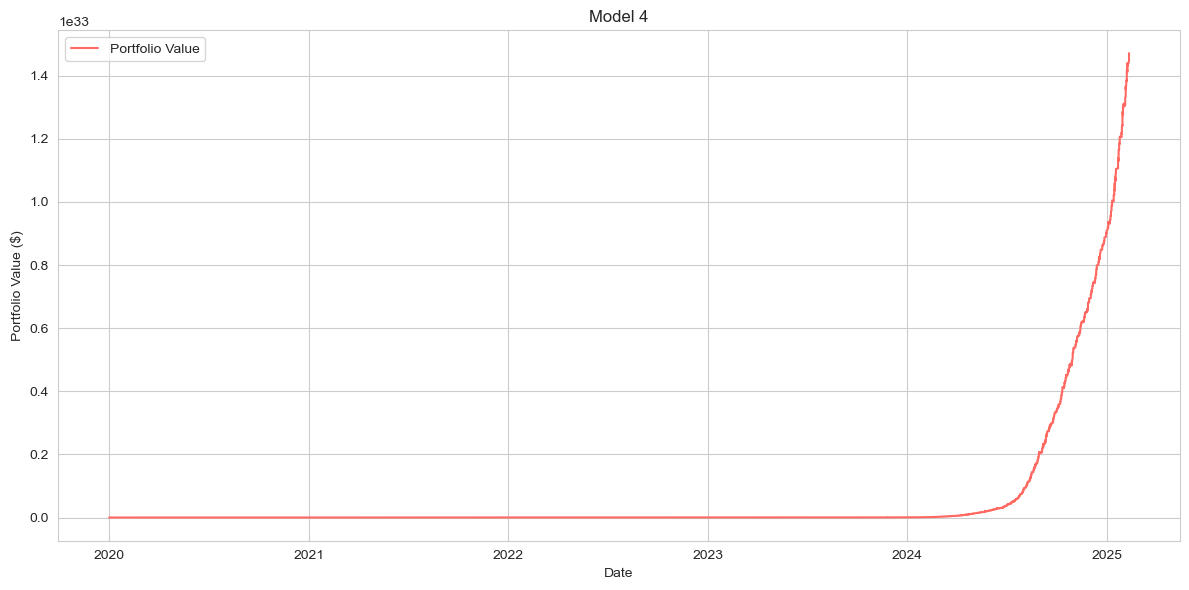


Capital Overview:
Initial Capital: $1,000,000.00
Final Portfolio Value: $1,465,049,067,841,108,898,852,728,089,870,336.00
Total Return: $1,465,049,067,841,108,898,852,728,089,870,336.00
Return on Investment (ROI): 146504906784110871420514336768.00%


In [32]:
df_features = prepare_features(df_sentiment)
df_labeled = label_data(df_features)
df_labeled["Date"] = pd.to_datetime(df_labeled["Date"])

train_df = df_labeled[df_labeled["Date"].dt.year <= 2014]
val_df = df_labeled[(df_labeled["Date"].dt.year >= 2015) & (df_labeled["Date"].dt.year <= 2019)]
test_df = df_labeled[df_labeled["Date"].dt.year >= 2020]

features = ["SMA_20", "SMA_50", "SMA_200", "RSI", "MACD", "MACD_Signal",
            "BB_Upper", "BB_Lower", "Fib_38.2", "Fib_50", "Fib_61.8",
            "Stochastic_%K", "Global_Weather_Impact_Score",
            "Seasonal_Weather_Impact_Score", "Average_Sentiment", "ATR"]

X_train, y_train = train_df[features], train_df["Signal"]
X_val, y_val = val_df[features], val_df["Signal"]
X_test, y_test = test_df[features], test_df["Signal"]

model = train_ensemble_model(train_df)

print("\U0001F9EA Validation Report:")
print(classification_report(y_val, model.predict(X_val)))
print("\n\U0001F4CA Test Report:")
print(classification_report(y_test, model.predict(X_test)))

df_backtest = backtest(test_df, model)
df_backtest = df_backtest[np.isfinite(df_backtest["Portfolio_Value"])]
metrics = evaluate_performance(df_backtest)
print("\nAlgo 3.3 Performance:")
for k, v in metrics.items():
    print(f"{k}: {v}")

plt.figure(figsize=(12, 6))
plt.plot(df_backtest["Date"], df_backtest["Portfolio_Value"], label="Portfolio Value", color="#FF6961")
plt.title("Model 4")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

initial_capital = 1_000_000
final_portfolio_value = df_backtest["Portfolio_Value"].iloc[-1]
total_return = final_portfolio_value - initial_capital
roi_percentage = (total_return / initial_capital) * 100

print("\nCapital Overview:")
print(f"Initial Capital: ${initial_capital:,.2f}")
print(f"Final Portfolio Value: ${final_portfolio_value:,.2f}")
print(f"Total Return: ${total_return:,.2f}")
print(f"Return on Investment (ROI): {roi_percentage:.2f}%")


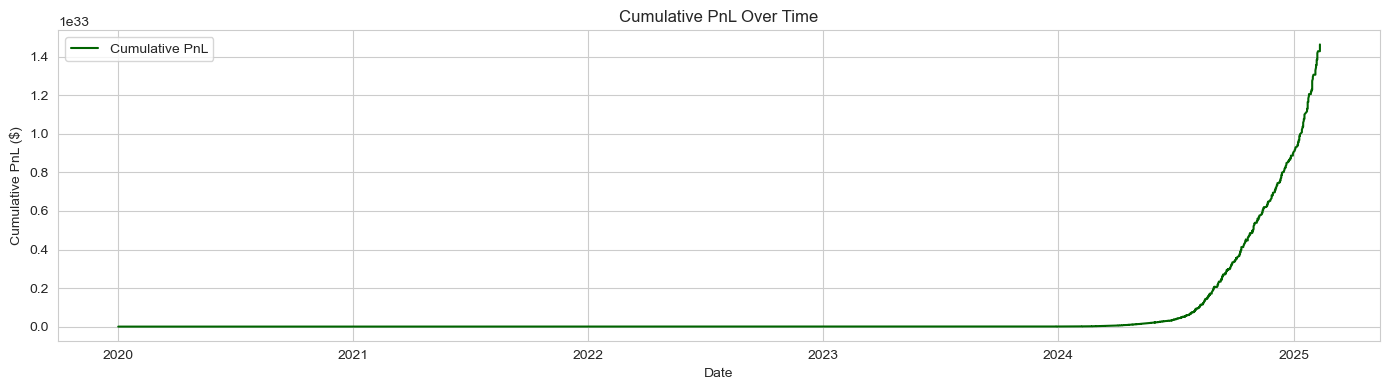

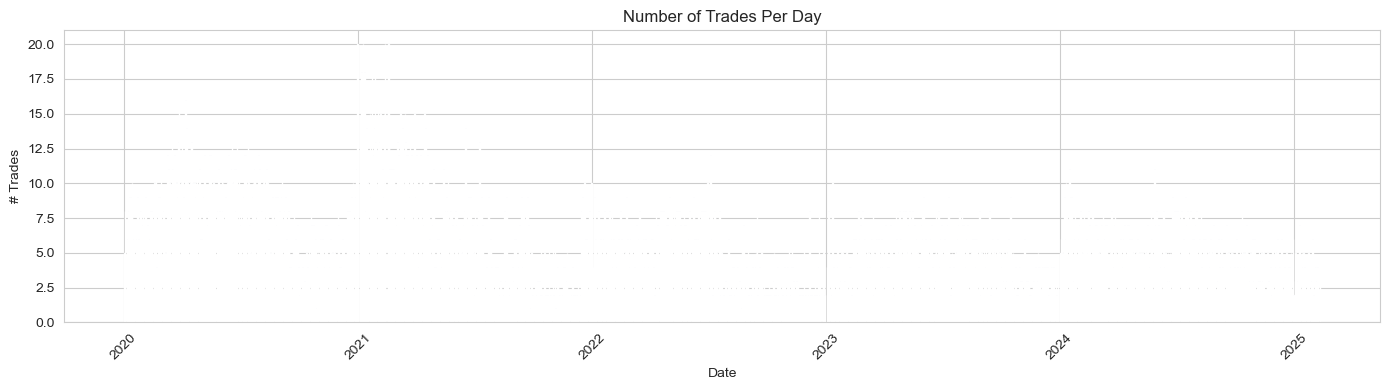

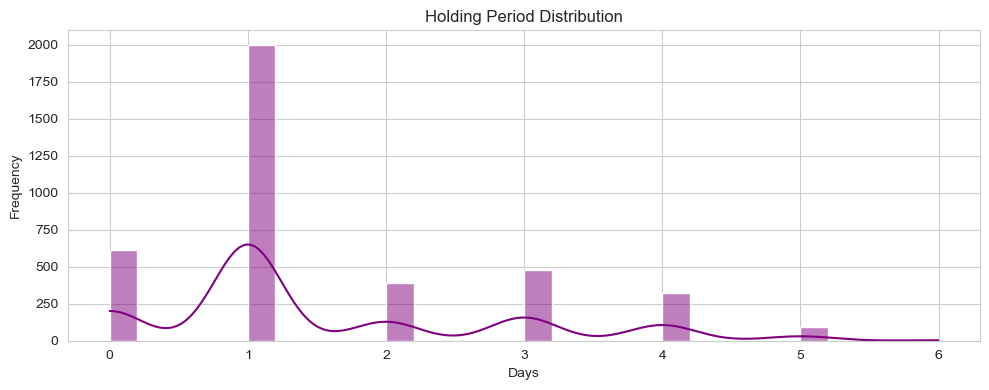

In [33]:
df_trades = pd.read_excel("algo3_trades.xlsx")

df_trades["Date"] = pd.to_datetime(df_trades["Date"])

df_trades["PnL"] = pd.to_numeric(df_trades["PnL"], errors="coerce").fillna(0)

df_trades = df_trades.sort_values("Date").reset_index(drop=True)

df_trades["Cumulative_PnL"] = df_trades["PnL"].cumsum()

trades_per_day = df_trades.groupby(df_trades["Date"].dt.date)["Action"].count()

buy_stack = []
holding_periods = []

for _, row in df_trades.iterrows():
    if row["Action"] == "BUY":
        buy_stack.append(row)
    elif row["Action"] == "SELL" and buy_stack:
        buy = buy_stack.pop(0)
        days_held = (row["Date"] - buy["Date"]).days
        holding_periods.append(days_held)

plt.figure(figsize=(14, 4))
plt.plot(df_trades["Date"], df_trades["Cumulative_PnL"], label="Cumulative PnL", color="darkgreen")
plt.title("Cumulative PnL Over Time")
plt.xlabel("Date")
plt.ylabel("Cumulative PnL ($)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.bar(trades_per_day.index, trades_per_day.values, color="cornflowerblue")
plt.title("Number of Trades Per Day")
plt.xlabel("Date")
plt.ylabel("# Trades")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.histplot(holding_periods, bins=30, kde=True, color="purple")
plt.title("Holding Period Distribution")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## Version 5 - Weather and Sentiment Integration

In [34]:
def compute_rsi(series, window):
    delta = series.diff()
    gain = np.where(delta > 0, delta, 0)
    loss = np.where(delta < 0, -delta, 0)
    avg_gain = pd.Series(gain).rolling(window=window).mean()
    avg_loss = pd.Series(loss).rolling(window=window).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

def prepare_features(df):
    df = df.copy()
    df["SMA_20"] = df["Price"].rolling(20).mean()
    df["SMA_50"] = df["Price"].rolling(50).mean()
    df["SMA_200"] = df["Price"].rolling(200).mean()
    df["RSI"] = compute_rsi(df["Price"], window=14)
    df["MACD"] = df["Price"].ewm(span=12, adjust=False).mean() - df["Price"].ewm(span=26, adjust=False).mean()
    df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()
    df["Stochastic_%K"] = (df["Price"] - df["Price"].rolling(14).min()) / (df["Price"].rolling(14).max() - df["Price"].rolling(14).min())
    df["BB_Upper"] = df["Price"].rolling(20).mean() + 2 * df["Price"].rolling(20).std()
    df["BB_Lower"] = df["Price"].rolling(20).mean() - 2 * df["Price"].rolling(20).std()
    high = df["Price"].rolling(50).max()
    low = df["Price"].rolling(50).min()
    df["Fib_38.2"] = high - (high - low) * 0.382
    df["Fib_50"] = high - (high - low) * 0.5
    df["Fib_61.8"] = high - (high - low) * 0.618
    df["ATR"] = df["Price"].rolling(14).std()
    return df

def calculate_optimized_score(df):
    weights = {
        "MACD_Signal": 0.3, "SMA_200": 0.2, "SMA_20": 0.15,
        "BB_Lower": 0.1, "MACD": 0.07, "SMA_50": 0.06,
        "BB_Upper": 0.06, "Fib_38.2": 0.05, "Fib_61.8": 0.05,
        "Fib_50": 0.04, "Stochastic_%K": 0.02, "RSI": 0.01
    }
    df["Technical_Score"] = sum(df[f] * w for f, w in weights.items())
    df["Buy_Signal"] = df["Technical_Score"] > 0.55
    df["Sell_Signal"] = df["Technical_Score"] < -0.55
    return df

def label_data(df):
    df = df.copy()
    df["Future_Price"] = df["Price"].shift(-5)
    df["Return"] = (df["Future_Price"] - df["Price"]) / df["Price"]
    df["Signal"] = np.where(df["Return"] > 0.01, 1, np.where(df["Return"] < -0.01, -1, 0))
    return df.drop(columns=["Future_Price", "Return"])

from sklearn.ensemble import RandomForestClassifier

def train_random_forest_model(X_train, y_train):
    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        class_weight="balanced"
    )
    model.fit(X_train, y_train)
    return model

def backtest(df, model, initial_capital=1_000_000, contract_size=100, max_allocation=0.2, min_holding_days=10):
    df = df.dropna().copy()
    features = ["MACD_Signal", "SMA_200", "SMA_20", "BB_Lower", "MACD", 
                "SMA_50", "BB_Upper", "Fib_38.2", "Fib_61.8", "Fib_50", 
                "Stochastic_%K", "RSI"]

    df["RF_Signal"] = model.predict(df[features])
    df["Final_Buy"] = df["Buy_Signal"] & (df["RF_Signal"] == 1)
    df["Final_Sell"] = df["Sell_Signal"] & (df["RF_Signal"] == -1)

    cash, position, entry_price, holding_days = initial_capital, 0, 0, 0
    portfolio_value, trades = [], []

    for i, row in df.iterrows():
        price = row["Price"]
        max_contracts = int((cash * max_allocation) // (price * contract_size))
        if row["Final_Sell"] and position > 0 and holding_days >= min_holding_days:
            cash += position * price * contract_size
            trades.append({"Date": row["Date"], "Action": "Sell", "Price": price, "Contracts": position})
            position = 0; holding_days = 0
        elif row["Final_Buy"] and position == 0:
            if max_contracts > 0:
                cost = max_contracts * price * contract_size
                if cost <= cash:
                    position = max_contracts
                    entry_price = price
                    cash -= cost
                    trades.append({"Date": row["Date"], "Action": "Buy", "Price": price, "Contracts": position})
                    holding_days = 0
        holding_days += 1 if position > 0 else 0
        portfolio_value.append(cash + position * price * contract_size)

    df["Portfolio_Value"] = portfolio_value
    return df, pd.DataFrame(trades)

def evaluate_performance(df):
    df = df.copy()
    df["Daily_Return"] = df["Portfolio_Value"].pct_change()
    sharpe = df["Daily_Return"].mean() / df["Daily_Return"].std() * np.sqrt(252)
    max_dd = ((df["Portfolio_Value"] / df["Portfolio_Value"].cummax()) - 1).min() * 100
    roi = (df["Portfolio_Value"].iloc[-1] - df["Portfolio_Value"].iloc[0]) / df["Portfolio_Value"].iloc[0] * 100
    return round(sharpe, 2), round(max_dd, 2), round(roi, 2)

def plot_portfolio(df):
    plt.figure(figsize=(12, 6))
    plt.plot(df["Date"], df["Portfolio_Value"], label="Portfolio Value", color="#CB99C9")
    plt.title("Model 5")
    plt.xlabel("Date"); plt.ylabel("Portfolio Value ($)")
    plt.grid(True); plt.tight_layout(); plt.legend(); plt.show()


🧪 Validation Report:
              precision    recall  f1-score   support

          -1       0.66      0.65      0.66      7882
           0       0.24      0.17      0.20      2680
           1       0.71      0.78      0.74      7872

    accuracy                           0.64     18434
   macro avg       0.54      0.54      0.53     18434
weighted avg       0.62      0.64      0.63     18434


📊 Test Report:
              precision    recall  f1-score   support

          -1       0.63      0.73      0.68      7954
           0       0.25      0.13      0.17      2593
           1       0.70      0.71      0.70      8011

    accuracy                           0.64     18558
   macro avg       0.53      0.52      0.52     18558
weighted avg       0.61      0.64      0.62     18558


ALGO 2.5 PERFORMANCE:
Sharpe Ratio: 0.16
Max Drawdown (%): -15.66
ROI (%): 2.57


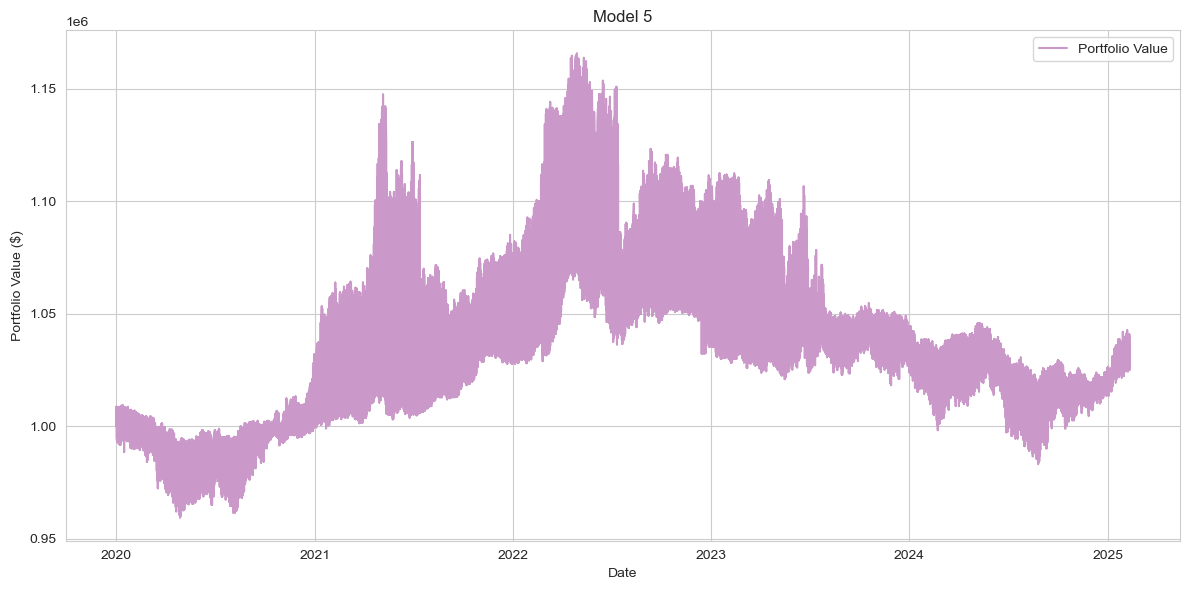


Capital Overview:
Initial Capital: $1,000,000.00
Final Portfolio Value: $1,025,700.00
Total Return: $25,700.00
Return on Investment (ROI): 2.57%

Performance Metrics:
Sharpe Ratio: 0.16
Max Drawdown: -15.66%
Profit Factor: 1.03
Win/Loss Ratio: 1.00


In [35]:
df_sentiment_algo4 = df_sentiment.copy()
df_features = prepare_features(df_sentiment_algo4)
df_scored = calculate_optimized_trading_score(df_features)
df_labeled = label_data(df_scored)
df_labeled["Date"] = pd.to_datetime(df_labeled["Date"])

train_df = df_labeled[df_labeled["Date"].dt.year <= 2014]
val_df   = df_labeled[(df_labeled["Date"].dt.year >= 2015) & (df_labeled["Date"].dt.year <= 2019)]
test_df  = df_labeled[df_labeled["Date"].dt.year >= 2020]

features = ["MACD_Signal", "SMA_200", "SMA_20", "BB_Lower", "MACD", 
            "SMA_50", "BB_Upper", "Fib_38.2", "Fib_61.8", "Fib_50", 
            "Stochastic_%K", "RSI"]

train_df = train_df.dropna(subset=features + ["Signal"])
val_df   = val_df.dropna(subset=features + ["Signal"])
test_df  = test_df.dropna(subset=features + ["Signal"])

X_train, y_train = train_df[features], train_df["Signal"]
X_val, y_val     = val_df[features], val_df["Signal"]
X_test, y_test   = test_df[features], test_df["Signal"]

model = train_random_forest_model(X_train, y_train)

print("\n\U0001F9EA Validation Report:")
print(classification_report(y_val, model.predict(X_val), zero_division=0))
print("\n\U0001F4CA Test Report:")
print(classification_report(y_test, model.predict(X_test), zero_division=0))

final_df, trades = backtest(test_df, model)
final_df = final_df[np.isfinite(final_df["Portfolio_Value"])]

sharpe, max_dd, roi = evaluate_performance(final_df)
print("\nALGO 2.5 PERFORMANCE:")
print(f"Sharpe Ratio: {sharpe}")
print(f"Max Drawdown (%): {max_dd}")
print(f"ROI (%): {roi}")

plot_portfolio(final_df)

initial_capital = 1_000_000
final_portfolio_value = final_df["Portfolio_Value"].iloc[-1]
total_return = final_portfolio_value - initial_capital
roi_percentage = (total_return / initial_capital) * 100

final_df["Daily_Return"] = final_df["Portfolio_Value"].pct_change()

sharpe_ratio = (final_df["Daily_Return"].mean() / final_df["Daily_Return"].std()) * np.sqrt(252)
max_drawdown = ((final_df["Portfolio_Value"] / final_df["Portfolio_Value"].cummax()) - 1).min() * 100

gains = final_df[final_df["Daily_Return"] > 0]["Daily_Return"].sum()
losses = -final_df[final_df["Daily_Return"] < 0]["Daily_Return"].sum()
profit_factor = gains / losses if losses != 0 else np.nan

win_trades = (final_df["Daily_Return"] > 0).sum()
loss_trades = (final_df["Daily_Return"] < 0).sum()
win_loss_ratio = win_trades / loss_trades if loss_trades > 0 else np.nan

print("\nCapital Overview:")
print(f"Initial Capital: ${initial_capital:,.2f}")
print(f"Final Portfolio Value: ${final_portfolio_value:,.2f}")
print(f"Total Return: ${total_return:,.2f}")
print(f"Return on Investment (ROI): {roi_percentage:.2f}%")

print("\nPerformance Metrics:")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Max Drawdown: {max_drawdown:.2f}%")
print(f"Profit Factor: {profit_factor:.2f}")
print(f"Win/Loss Ratio: {win_loss_ratio:.2f}")



## Version 6 - Contract-Aware Execution Model

In [36]:
def compute_rsi(series, window):
    delta = series.diff()
    gain = np.where(delta > 0, delta, 0)
    loss = np.where(delta < 0, -delta, 0)
    avg_gain = pd.Series(gain).rolling(window=window).mean()
    avg_loss = pd.Series(loss).rolling(window=window).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

def prepare_features(df):
    df = df.copy()
    df["SMA_20"] = df["Price"].rolling(20).mean()
    df["SMA_50"] = df["Price"].rolling(50).mean()
    df["SMA_200"] = df["Price"].rolling(200).mean()
    df["RSI"] = compute_rsi(df["Price"], 14)
    df["MACD"] = df["Price"].ewm(span=12, adjust=False).mean() - df["Price"].ewm(span=26, adjust=False).mean()
    df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()
    df["Stochastic_%K"] = (df["Price"] - df["Price"].rolling(14).min()) / (df["Price"].rolling(14).max() - df["Price"].rolling(14).min())
    df["BB_Upper"] = df["Price"].rolling(20).mean() + 2 * df["Price"].rolling(20).std()
    df["BB_Lower"] = df["Price"].rolling(20).mean() - 2 * df["Price"].rolling(20).std()
    high = df["Price"].rolling(50).max()
    low = df["Price"].rolling(50).min()
    df["Fib_38.2"] = high - (high - low) * 0.382
    df["Fib_50"] = high - (high - low) * 0.5
    df["Fib_61.8"] = high - (high - low) * 0.618
    df["ATR"] = df["Price"].rolling(14).std()
    return df

def flag_extreme_events(df, sentiment_thresh=0.6, weather_thresh=0.7):
    df["Extreme_Condition"] = (
        (df["Average_Sentiment"].abs() > sentiment_thresh) |
        (df["Global_Weather_Impact_Score"].abs() > weather_thresh)
    )
    return df

def calculate_optimized_score(df):
    weights = {
        "MACD_Signal": 0.25, "SMA_200": 0.15, "SMA_20": 0.10,
        "BB_Lower": 0.08, "MACD": 0.05, "SMA_50": 0.05,
        "BB_Upper": 0.05, "Fib_38.2": 0.04, "Fib_61.8": 0.04,
        "Fib_50": 0.03, "Stochastic_%K": 0.01, "RSI": 0.01,
        "Global_Weather_Impact_Score": 0.10, "Seasonal_Weather_Impact_Score": 0.08
    }
    df["Technical_Score"] = sum(df[f] * w for f, w in weights.items() if f in df.columns)
    df["Buy_Signal"] = df["Technical_Score"] > 0.55
    df["Sell_Signal"] = df["Technical_Score"] < -0.55

    df["Buy_Signal"] = df["Buy_Signal"] | ((df["Extreme_Condition"]) & (df["Average_Sentiment"] > 0.4))
    df["Sell_Signal"] = df["Sell_Signal"] | ((df["Extreme_Condition"]) & (df["Average_Sentiment"] < -0.4))
    return df

def label_data(df):
    df["Future_Price"] = df["Price"].shift(-5)
    df["Return"] = (df["Future_Price"] - df["Price"]) / df["Price"]
    df["Signal"] = np.where(df["Return"] > 0.01, 1, np.where(df["Return"] < -0.01, -1, 0))
    return df.drop(columns=["Future_Price", "Return"])

def train_random_forest_model(X_train, y_train):
    model = RandomForestClassifier(n_estimators=300, max_depth=15, min_samples_split=5, min_samples_leaf=2,
                                   random_state=42, class_weight="balanced")
    model.fit(X_train, y_train)
    return model

def backtest(df, model, initial_capital=1_000_000, contract_size=100, max_allocation=0.2, min_holding_days=10):
    df = df.dropna().copy()
    features = ["MACD_Signal", "SMA_200", "SMA_20", "BB_Lower", "MACD", 
                "SMA_50", "BB_Upper", "Fib_38.2", "Fib_61.8", "Fib_50", 
                "Stochastic_%K", "RSI", "Global_Weather_Impact_Score", "Seasonal_Weather_Impact_Score"]

    df["RF_Signal"] = model.predict(df[features])
    df["Final_Buy"] = df["Buy_Signal"] & (df["RF_Signal"] == 1)
    df["Final_Sell"] = df["Sell_Signal"] & (df["RF_Signal"] == -1)

    cash, position, entry_price, holding_days = initial_capital, 0, 0, 0
    portfolio_value, trades = [], []

    for _, row in df.iterrows():
        price = row["Price"]
        max_contracts = int((cash * max_allocation) // (price * contract_size))

        if row["Final_Sell"] and position > 0 and holding_days >= min_holding_days:
            cash += position * price * contract_size
            trades.append({"Date": row["Date"], "Action": "Sell", "Price": price, "Contracts": position})
            position = 0; holding_days = 0
        elif row["Final_Buy"] and position == 0 and max_contracts > 0:
            cost = max_contracts * price * contract_size
            if cost <= cash:
                position = max_contracts
                entry_price = price
                cash -= cost
                trades.append({"Date": row["Date"], "Action": "Buy", "Price": price, "Contracts": position})
                holding_days = 0

        holding_days += 1 if position > 0 else 0
        portfolio_value.append(cash + position * price * contract_size)

    df["Portfolio_Value"] = portfolio_value
    return df, pd.DataFrame(trades)

def evaluate_performance(df):
    df = df.copy()
    df["Daily_Return"] = df["Portfolio_Value"].pct_change()
    sharpe = df["Daily_Return"].mean() / df["Daily_Return"].std() * np.sqrt(252)
    max_dd = ((df["Portfolio_Value"] / df["Portfolio_Value"].cummax()) - 1).min() * 100
    roi = (df["Portfolio_Value"].iloc[-1] - df["Portfolio_Value"].iloc[0]) / df["Portfolio_Value"].iloc[0] * 100
    return round(sharpe, 2), round(max_dd, 2), round(roi, 2)

def plot_portfolio(df):
    plt.figure(figsize=(12, 6))
    plt.plot(df["Date"], df["Portfolio_Value"], label="Portfolio Value", color="#FDFD96")
    plt.title("Model 6")
    plt.xlabel("Date")
    plt.ylabel("Portfolio Value ($)")
    plt.grid(True)
    plt.tight_layout()
    plt.legend()
    plt.show()




Validation Report:
              precision    recall  f1-score   support

          -1       0.66      0.68      0.67      7882
           0       0.24      0.12      0.16      2680
           1       0.70      0.79      0.74      7872

    accuracy                           0.65     18434
   macro avg       0.53      0.53      0.53     18434
weighted avg       0.62      0.65      0.63     18434


Test Report:
              precision    recall  f1-score   support

          -1       0.64      0.73      0.68      7954
           0       0.24      0.11      0.15      2593
           1       0.70      0.71      0.70      8011

    accuracy                           0.64     18558
   macro avg       0.52      0.52      0.51     18558
weighted avg       0.61      0.64      0.62     18558


ALGO 2.6 PERFORMANCE:
Sharpe Ratio: 0.16
Max Drawdown: -15.66%
ROI: 2.57%


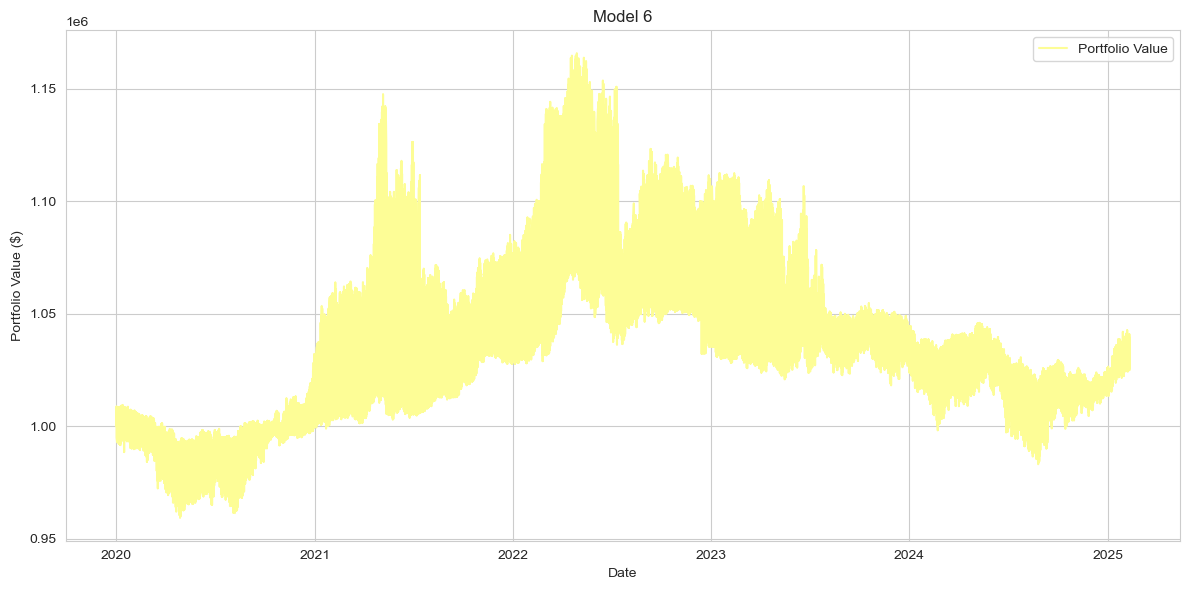

Trade log saved to 'algo2_6_trades.xlsx'

Capital Overview:
Initial Capital: $1,000,000.00
Final Portfolio Value: $1,025,700.00
Total Return: $25,700.00
Return on Investment (ROI): 2.57%

Full Performance Metrics:
Sharpe Ratio: 0.16
Max Drawdown: -15.66%
Profit Factor: 1.03
Win/Loss Ratio: 1.00


In [37]:
df_sentiment_algo5 = df_sentiment.copy()
df_features = prepare_features(df_sentiment_algo5)
df_flagged = flag_extreme_events(df_features)  # 🔥 Flag based on sentiment/weather
df_scored = calculate_optimized_score(df_flagged)
df_labeled = label_data(df_scored)
df_labeled["Date"] = pd.to_datetime(df_labeled["Date"])

train = df_labeled[df_labeled["Date"].dt.year <= 2014]
val   = df_labeled[(df_labeled["Date"].dt.year >= 2015) & (df_labeled["Date"].dt.year <= 2019)]
test  = df_labeled[df_labeled["Date"].dt.year >= 2020]

features = ["MACD_Signal", "SMA_200", "SMA_20", "BB_Lower", "MACD", 
            "SMA_50", "BB_Upper", "Fib_38.2", "Fib_61.8", "Fib_50", 
            "Stochastic_%K", "RSI", "Global_Weather_Impact_Score", "Seasonal_Weather_Impact_Score"]

train = train.dropna(subset=features + ["Signal"])
val   = val.dropna(subset=features + ["Signal"])
test  = test.dropna(subset=features + ["Signal"])

X_train, y_train = train[features], train["Signal"]
X_val, y_val     = val[features], val["Signal"]
X_test, y_test   = test[features], test["Signal"]

model = train_random_forest_model(X_train, y_train)

print("\nValidation Report:")
print(classification_report(y_val, model.predict(X_val), zero_division=0))
print("\nTest Report:")
print(classification_report(y_test, model.predict(X_test), zero_division=0))

df_backtest, trade_log = backtest(test.copy(), model)
df_backtest = df_backtest[np.isfinite(df_backtest["Portfolio_Value"])]

sharpe, max_dd, roi = evaluate_performance(df_backtest)
print("\nALGO 2.6 PERFORMANCE:")
print(f"Sharpe Ratio: {sharpe}")
print(f"Max Drawdown: {max_dd:.2f}%")
print(f"ROI: {roi:.2f}%")

plot_portfolio(df_backtest)

trade_log.to_excel("algo2_6_trades.xlsx", index=False)
print("Trade log saved to 'algo2_6_trades.xlsx'")

initial_capital = 1_000_000
final_portfolio_value = df_backtest["Portfolio_Value"].iloc[-1]
total_return = final_portfolio_value - initial_capital
roi_percentage = (total_return / initial_capital) * 100

df_backtest["Daily_Return"] = df_backtest["Portfolio_Value"].pct_change()

sharpe_ratio = (df_backtest["Daily_Return"].mean() / df_backtest["Daily_Return"].std()) * np.sqrt(252)
max_drawdown = ((df_backtest["Portfolio_Value"] / df_backtest["Portfolio_Value"].cummax()) - 1).min() * 100

gains = df_backtest[df_backtest["Daily_Return"] > 0]["Daily_Return"].sum()
losses = -df_backtest[df_backtest["Daily_Return"] < 0]["Daily_Return"].sum()
profit_factor = gains / losses if losses != 0 else np.nan

win_trades = (df_backtest["Daily_Return"] > 0).sum()
loss_trades = (df_backtest["Daily_Return"] < 0).sum()
win_loss_ratio = win_trades / loss_trades if loss_trades > 0 else np.nan

print("\nCapital Overview:")
print(f"Initial Capital: ${initial_capital:,.2f}")
print(f"Final Portfolio Value: ${final_portfolio_value:,.2f}")
print(f"Total Return: ${total_return:,.2f}")
print(f"Return on Investment (ROI): {roi_percentage:.2f}%")

print("\nFull Performance Metrics:")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Max Drawdown: {max_drawdown:.2f}%")
print(f"Profit Factor: {profit_factor:.2f}")
print(f"Win/Loss Ratio: {win_loss_ratio:.2f}")


## Version 7 - Long-term Capital-Constrained Strategy 

In [38]:
def compute_rsi(series, window):
    delta = series.diff()
    gain = np.where(delta > 0, delta, 0)
    loss = np.where(delta < 0, -delta, 0)
    avg_gain = pd.Series(gain).rolling(window=window).mean()
    avg_loss = pd.Series(loss).rolling(window=window).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

def prepare_features(df):
    df = df.copy()
    df["SMA_20"] = df["Price"].rolling(20).mean()
    df["SMA_50"] = df["Price"].rolling(50).mean()
    df["SMA_200"] = df["Price"].rolling(200).mean()
    df["RSI"] = compute_rsi(df["Price"], 14)
    df["MACD"] = df["Price"].ewm(span=12).mean() - df["Price"].ewm(span=26).mean()
    df["MACD_Signal"] = df["MACD"].ewm(span=9).mean()
    df["Stochastic_%K"] = (df["Price"] - df["Price"].rolling(14).min()) / (df["Price"].rolling(14).max() - df["Price"].rolling(14).min())
    df["BB_Upper"] = df["Price"].rolling(20).mean() + 2 * df["Price"].rolling(20).std()
    df["BB_Lower"] = df["Price"].rolling(20).mean() - 2 * df["Price"].rolling(20).std()
    high = df["Price"].rolling(50).max()
    low = df["Price"].rolling(50).min()
    df["Fib_38.2"] = high - (high - low) * 0.382
    df["Fib_50"] = high - (high - low) * 0.5
    df["Fib_61.8"] = high - (high - low) * 0.618
    df["ATR"] = df["Price"].rolling(14).std()
    df["Volatility"] = df["Price"].pct_change().rolling(20).std()
    return df

def generate_extreme_flags(df):
    df = df.copy()
    df["Sentiment_Z"] = (df["Average_Sentiment"] - df["Average_Sentiment"].rolling(60).mean()) / df["Average_Sentiment"].rolling(60).std()
    df["Extreme_Condition"] = (df["Volatility"] > df["Volatility"].quantile(0.95)) | (df["Sentiment_Z"].abs() > 2)
    return df

def calculate_signals(df):
    weights = {
        "MACD_Signal": 0.25, "SMA_200": 0.15, "SMA_20": 0.10,
        "BB_Lower": 0.08, "MACD": 0.05, "SMA_50": 0.05, "BB_Upper": 0.05,
        "Fib_38.2": 0.04, "Fib_61.8": 0.04, "Fib_50": 0.03,
        "Stochastic_%K": 0.01, "RSI": 0.01,
        "Global_Weather_Impact_Score": 0.10, "Seasonal_Weather_Impact_Score": 0.08
    }
    df["Technical_Score"] = sum(df[f] * w for f, w in weights.items() if f in df.columns)
    df["Buy_Signal"] = df["Technical_Score"] > 0.55
    df["Sell_Signal"] = df["Technical_Score"] < -0.55
    df["Buy_Signal"] |= (df["Extreme_Condition"] & (df["Average_Sentiment"] > 0.4) & (df["Global_Weather_Impact_Score"] > 0))
    df["Sell_Signal"] |= (df["Extreme_Condition"] & (df["Average_Sentiment"] < -0.4) & (df["Global_Weather_Impact_Score"] < 0))
    return df

def label_data(df):
    df["Future_Price"] = df["Price"].shift(-5)
    df["Return"] = (df["Future_Price"] - df["Price"]) / df["Price"]
    df["Signal"] = np.where(df["Return"] > 0.01, 1, np.where(df["Return"] < -0.01, -1, 0))
    return df.drop(columns=["Future_Price", "Return"])

def train_rf(X_train, y_train):
    model = RandomForestClassifier(
        n_estimators=300, max_depth=15, min_samples_split=5, min_samples_leaf=2,
        class_weight="balanced", random_state=42
    )
    model.fit(X_train, y_train)
    return model

def backtest(df, model, contract_size=100, initial_capital=1_000_000, max_allocation=0.2, min_holding_days=10, conf_thresh=0.6):
    df = df.copy()
    features = [
        "MACD_Signal", "SMA_200", "SMA_20", "BB_Lower", "MACD", "SMA_50",
        "BB_Upper", "Fib_38.2", "Fib_61.8", "Fib_50", "Stochastic_%K", "RSI",
        "Global_Weather_Impact_Score", "Seasonal_Weather_Impact_Score"
    ]

    proba = model.predict_proba(df[features])
    pred = model.predict(df[features])
    max_conf = proba.max(axis=1)
    df["RF_Signal"] = np.where(max_conf >= conf_thresh, pred, 0)

    df["Final_Buy"] = df["Buy_Signal"] & (df["RF_Signal"] == 1)
    df["Final_Sell"] = df["Sell_Signal"] & (df["RF_Signal"] == -1)

    cash, position, holding_days = initial_capital, 0, 0
    portfolio_value, trades = [], []

    for _, row in df.iterrows():
        price = row["Price"]
        if row["Volatility"] > df["Volatility"].quantile(0.95):
            portfolio_value.append(cash + position * price * contract_size)
            holding_days += 1 if position > 0 else 0
            continue

        sentiment_factor = max(1.0, min(1.5, 1 + abs(row["Average_Sentiment"])))
        weather_factor = max(0.75, min(1.25, 1 + abs(row["Global_Weather_Impact_Score"])))
        position_factor = sentiment_factor * weather_factor

        max_contracts = int((cash * max_allocation * position_factor) // (price * contract_size))

        if row["Final_Sell"] and position > 0 and holding_days >= min_holding_days:
            cash += position * price * contract_size
            trades.append({"Date": row["Date"], "Action": "Sell", "Price": price, "Contracts": position})
            position = 0; holding_days = 0
        elif row["Final_Buy"] and position == 0 and max_contracts > 0:
            cost = max_contracts * price * contract_size
            if cost <= cash:
                position = max_contracts
                cash -= cost
                trades.append({"Date": row["Date"], "Action": "Buy", "Price": price, "Contracts": position})
                holding_days = 0

        if position > 0:
            holding_days += 1

        portfolio_value.append(cash + position * price * contract_size)

    df["Portfolio_Value"] = portfolio_value
    return df, pd.DataFrame(trades)

def evaluate(df):
    df["Daily_Return"] = df["Portfolio_Value"].pct_change()
    sharpe = df["Daily_Return"].mean() / df["Daily_Return"].std() * np.sqrt(252)
    max_dd = ((df["Portfolio_Value"] / df["Portfolio_Value"].cummax()) - 1).min() * 100
    roi = (df["Portfolio_Value"].iloc[-1] - df["Portfolio_Value"].iloc[0]) / df["Portfolio_Value"].iloc[0] * 100
    return round(sharpe, 2), round(max_dd, 2), round(roi, 2)

def plot_portfolio(df):
    plt.figure(figsize=(12, 6))
    plt.plot(df["Date"], df["Portfolio_Value"], label="Portfolio Value", color="#84B6F4")
    plt.title("Model 7")
    plt.xlabel("Date"); plt.ylabel("Portfolio Value ($)")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout(); plt.legend(); plt.show()


Train shape: (46791, 33)
Validation shape: (18434, 33)
Test shape: (18558, 33)

Validation Report:
              precision    recall  f1-score   support

          -1       0.66      0.68      0.67      7882
           0       0.24      0.12      0.16      2680
           1       0.70      0.79      0.74      7872

    accuracy                           0.65     18434
   macro avg       0.53      0.53      0.53     18434
weighted avg       0.62      0.65      0.63     18434


Test Report:
              precision    recall  f1-score   support

          -1       0.64      0.73      0.68      7954
           0       0.24      0.11      0.15      2593
           1       0.70      0.71      0.70      8011

    accuracy                           0.64     18558
   macro avg       0.52      0.52      0.51     18558
weighted avg       0.61      0.64      0.62     18558


ALGO 2.8 PERFORMANCE:
Sharpe Ratio: 0.24
Max Drawdown: -21.93%
ROI: 3.86%


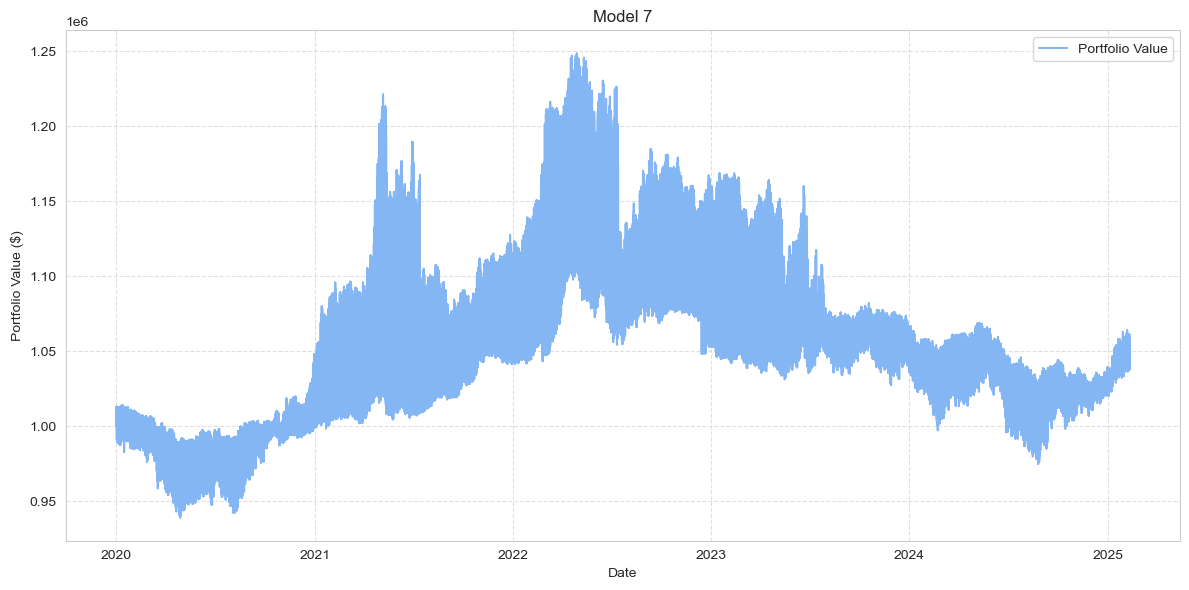

Trade log saved to 'algo2_8_trades.xlsx'

Capital Overview:
Initial Capital: $1,000,000.00
Final Portfolio Value: $1,038,550.00
Total Return: $38,550.00
Return on Investment (ROI): 3.85%

Full Performance Metrics:
Sharpe Ratio: 0.24
Max Drawdown: -21.93%
Profit Factor: 1.04
Win/Loss Ratio: 1.00


In [39]:
df_algo28 = df_sentiment.copy()
df_algo28["Date"] = pd.to_datetime(df_algo28["Date"])

df_feat = prepare_features(df_algo28)
df_ext = generate_extreme_flags(df_feat)
df_score = calculate_signals(df_ext)
df_labeled = label_data(df_score)

train = df_labeled[df_labeled["Date"].dt.year <= 2014]
val   = df_labeled[(df_labeled["Date"].dt.year >= 2015) & (df_labeled["Date"].dt.year <= 2019)]
test  = df_labeled[df_labeled["Date"].dt.year >= 2020]
features = [
    "MACD_Signal", "SMA_200", "SMA_20", "BB_Lower", "MACD", "SMA_50",
    "BB_Upper", "Fib_38.2", "Fib_61.8", "Fib_50", "Stochastic_%K", "RSI",
    "Global_Weather_Impact_Score", "Seasonal_Weather_Impact_Score"
]

train = train.dropna(subset=features + ["Signal"])
val   = val.dropna(subset=features + ["Signal"])
test  = test.dropna(subset=features + ["Signal"])

print("Train shape:", train.shape)
print("Validation shape:", val.shape)
print("Test shape:", test.shape)
X_train, y_train = train[features], train["Signal"]
X_val, y_val     = val[features], val["Signal"]
X_test, y_test   = test[features], test["Signal"]


model = train_rf(X_train, y_train)

print("\nValidation Report:")
print(classification_report(y_val, model.predict(X_val), zero_division=0))
print("\nTest Report:")
print(classification_report(y_test, model.predict(X_test), zero_division=0))

df_backtest, trade_log = backtest(test.copy(), model)
df_backtest = df_backtest[np.isfinite(df_backtest["Portfolio_Value"])]
sharpe, max_dd, roi = evaluate(df_backtest)

print("\nALGO 2.8 PERFORMANCE:")
print(f"Sharpe Ratio: {sharpe}")
print(f"Max Drawdown: {max_dd:.2f}%")
print(f"ROI: {roi:.2f}%")

plot_portfolio(df_backtest)

trade_log.to_excel("algo2_8_trades.xlsx", index=False)
print("Trade log saved to 'algo2_8_trades.xlsx'")

initial_capital = 1_000_000
final_portfolio_value = df_backtest["Portfolio_Value"].iloc[-1]
total_return = final_portfolio_value - initial_capital
roi_percentage = (total_return / initial_capital) * 100

df_backtest["Daily_Return"] = df_backtest["Portfolio_Value"].pct_change()

sharpe_ratio = (df_backtest["Daily_Return"].mean() / df_backtest["Daily_Return"].std()) * np.sqrt(252)
max_drawdown = ((df_backtest["Portfolio_Value"] / df_backtest["Portfolio_Value"].cummax()) - 1).min() * 100

gains = df_backtest[df_backtest["Daily_Return"] > 0]["Daily_Return"].sum()
losses = -df_backtest[df_backtest["Daily_Return"] < 0]["Daily_Return"].sum()
profit_factor = gains / losses if losses != 0 else np.nan

win_trades = (df_backtest["Daily_Return"] > 0).sum()
loss_trades = (df_backtest["Daily_Return"] < 0).sum()
win_loss_ratio = win_trades / loss_trades if loss_trades > 0 else np.nan

print("\nCapital Overview:")
print(f"Initial Capital: ${initial_capital:,.2f}")
print(f"Final Portfolio Value: ${final_portfolio_value:,.2f}")
print(f"Total Return: ${total_return:,.2f}")
print(f"Return on Investment (ROI): {roi_percentage:.2f}%")

print("\nFull Performance Metrics:")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Max Drawdown: {max_drawdown:.2f}%")
print(f"Profit Factor: {profit_factor:.2f}")
print(f"Win/Loss Ratio: {win_loss_ratio:.2f}")


## Version 8 - Moderate Risk Optimized Model


Validation Report:
              precision    recall  f1-score   support

          -1       0.66      0.67      0.66      7882
           0       0.25      0.16      0.20      2680
           1       0.71      0.78      0.74      7872

    accuracy                           0.64     18434
   macro avg       0.54      0.54      0.54     18434
weighted avg       0.62      0.64      0.63     18434


Test Report:
              precision    recall  f1-score   support

          -1       0.63      0.74      0.68      7954
           0       0.28      0.14      0.19      2593
           1       0.71      0.70      0.71      8011

    accuracy                           0.64     18558
   macro avg       0.54      0.53      0.52     18558
weighted avg       0.62      0.64      0.62     18558


Strategy Performance Metrics:
Sharpe Ratio: 0.2
Max Drawdown (%): -21.93
ROI (%): 3.86
Profit Factor: 1.04
Win/Loss Ratio: 1.0


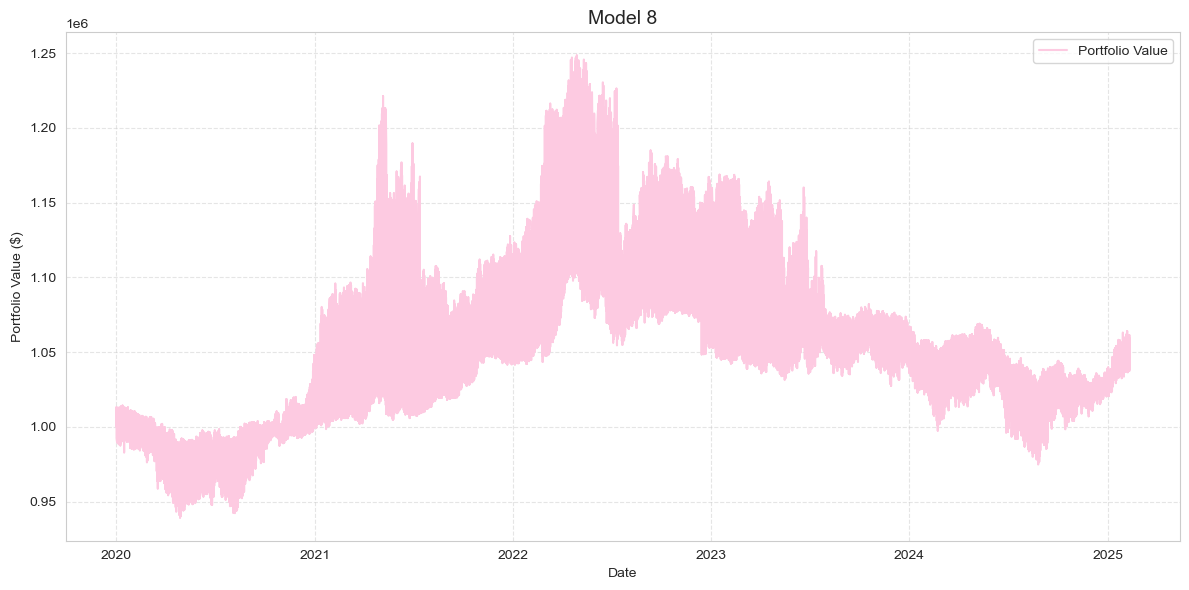


Capital Overview:
Initial Capital: $1,000,000.00
Final Portfolio Value: $1,038,550.00
Total Return: $38,550.00
Return on Investment (ROI): 3.85%

Full Performance Metrics:
Sharpe Ratio: 0.24
Max Drawdown: -21.93%
Profit Factor: 1.04
Win/Loss Ratio: 1.00


In [40]:
def compute_rsi(series, window):
    delta = series.diff()
    gain = np.where(delta > 0, delta, 0)
    loss = np.where(delta < 0, -delta, 0)
    avg_gain = pd.Series(gain).rolling(window=window).mean()
    avg_loss = pd.Series(loss).rolling(window=window).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

def prepare_features(df):
    df = df.copy()
    df["SMA_20"] = df["Price"].rolling(20).mean()
    df["SMA_50"] = df["Price"].rolling(50).mean()
    df["SMA_200"] = df["Price"].rolling(200).mean()
    df["RSI"] = compute_rsi(df["Price"], 14)
    df["MACD"] = df["Price"].ewm(span=12).mean() - df["Price"].ewm(span=26).mean()
    df["MACD_Signal"] = df["MACD"].ewm(span=9).mean()
    df["Stochastic_%K"] = (df["Price"] - df["Price"].rolling(14).min()) / (df["Price"].rolling(14).max() - df["Price"].rolling(14).min())
    df["BB_Upper"] = df["Price"].rolling(20).mean() + 2 * df["Price"].rolling(20).std()
    df["BB_Lower"] = df["Price"].rolling(20).mean() - 2 * df["Price"].rolling(20).std()
    high = df["Price"].rolling(50).max()
    low = df["Price"].rolling(50).min()
    df["Fib_38.2"] = high - (high - low) * 0.382
    df["Fib_50"] = high - (high - low) * 0.5
    df["Fib_61.8"] = high - (high - low) * 0.618
    df["Volatility"] = df["Price"].pct_change().rolling(20).std()
    return df

def label_and_tag(df):
    df["Future_Price"] = df["Price"].shift(-5)
    df["Return"] = (df["Future_Price"] - df["Price"]) / df["Price"]
    df["Signal"] = np.where(df["Return"] > 0.01, 1, np.where(df["Return"] < -0.01, -1, 0))

    df["Strategy"] = "balanced"
    df.loc[df["Volatility"] > df["Volatility"].quantile(0.85), "Strategy"] = "aggressive"
    df.loc[df["Volatility"] < df["Volatility"].quantile(0.2), "Strategy"] = "conservative"
    return df.drop(columns=["Future_Price", "Return"])

def train_meta_model(X_train, y_train):
    clf = RandomForestClassifier(n_estimators=300, max_depth=15, min_samples_split=5, min_samples_leaf=2,
                                 class_weight="balanced", random_state=42)
    clf.fit(X_train, y_train)
    return clf

df = df_sentiment.copy()
df["Date"] = pd.to_datetime(df["Date"])
df = prepare_features(df)
df = label_and_tag(df)

features = [
    "MACD_Signal", "SMA_200", "SMA_20", "BB_Lower", "MACD", "SMA_50",
    "BB_Upper", "Fib_38.2", "Fib_61.8", "Fib_50", "Stochastic_%K", "RSI",
    "Global_Weather_Impact_Score", "Seasonal_Weather_Impact_Score", "Volatility"
]

df = df.dropna(subset=features + ["Signal", "Strategy"])

train = df[df["Date"].dt.year <= 2014]
val = df[(df["Date"].dt.year >= 2015) & (df["Date"].dt.year <= 2019)]
test = df[df["Date"].dt.year >= 2020]

X_train = pd.get_dummies(train[features + ["Strategy"]], drop_first=True)
X_val = pd.get_dummies(val[features + ["Strategy"]], drop_first=True)
X_test = pd.get_dummies(test[features + ["Strategy"]], drop_first=True)

X_val = X_val[X_train.columns]
X_test = X_test[X_train.columns]

y_train = train["Signal"]
y_val = val["Signal"]
y_test = test["Signal"]

model = train_meta_model(X_train, y_train)

print("\nValidation Report:")
print(classification_report(y_val, model.predict(X_val), zero_division=0))

print("\nTest Report:")
print(classification_report(y_test, model.predict(X_test), zero_division=0))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def calculate_performance_metrics(df, risk_free_rate=0.02):
    df = df.copy()
    df["Daily_Return"] = df["Portfolio_Value"].pct_change()

    sharpe = (df["Daily_Return"].mean() - risk_free_rate / 252) / df["Daily_Return"].std() * np.sqrt(252)
    max_dd = ((df["Portfolio_Value"] / df["Portfolio_Value"].cummax()) - 1).min() * 100
    roi = (df["Portfolio_Value"].iloc[-1] - df["Portfolio_Value"].iloc[0]) / df["Portfolio_Value"].iloc[0] * 100

    gains = df[df["Daily_Return"] > 0]["Daily_Return"].sum()
    losses = abs(df[df["Daily_Return"] < 0]["Daily_Return"].sum())
    profit_factor = gains / losses if losses > 0 else np.nan

    win_ratio = (df["Daily_Return"] > 0).sum() / max((df["Daily_Return"] < 0).sum(), 1)

    return {
        "Sharpe Ratio": round(sharpe, 2),
        "Max Drawdown (%)": round(max_dd, 2),
        "ROI (%)": round(roi, 2),
        "Profit Factor": round(profit_factor, 2),
        "Win/Loss Ratio": round(win_ratio, 2)
    }

metrics = calculate_performance_metrics(df_backtest)

print("\nStrategy Performance Metrics:")
for k, v in metrics.items():
    print(f"{k}: {v}")

plt.figure(figsize=(12, 6))
plt.plot(df_backtest["Date"], df_backtest["Portfolio_Value"], color="#FDCAE1", label="Portfolio Value")
plt.title("Model 8", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.legend()
plt.show()

initial_capital = 1_000_000
final_portfolio_value = df_backtest["Portfolio_Value"].iloc[-1]
total_return = final_portfolio_value - initial_capital
roi_percentage = (total_return / initial_capital) * 100

df_backtest["Daily_Return"] = df_backtest["Portfolio_Value"].pct_change()

sharpe_ratio = (df_backtest["Daily_Return"].mean() / df_backtest["Daily_Return"].std()) * np.sqrt(252)
max_drawdown = ((df_backtest["Portfolio_Value"] / df_backtest["Portfolio_Value"].cummax()) - 1).min() * 100

gains = df_backtest[df_backtest["Daily_Return"] > 0]["Daily_Return"].sum()
losses = -df_backtest[df_backtest["Daily_Return"] < 0]["Daily_Return"].sum()
profit_factor = gains / losses if losses != 0 else np.nan

win_trades = (df_backtest["Daily_Return"] > 0).sum()
loss_trades = (df_backtest["Daily_Return"] < 0).sum()
win_loss_ratio = win_trades / loss_trades if loss_trades > 0 else np.nan

print("\nCapital Overview:")
print(f"Initial Capital: ${initial_capital:,.2f}")
print(f"Final Portfolio Value: ${final_portfolio_value:,.2f}")
print(f"Total Return: ${total_return:,.2f}")
print(f"Return on Investment (ROI): {roi_percentage:.2f}%")

print("\nFull Performance Metrics:")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Max Drawdown: {max_drawdown:.2f}%")
print(f"Profit Factor: {profit_factor:.2f}")
print(f"Win/Loss Ratio: {win_loss_ratio:.2f}")


## Version 9 - Diversified Risk Allocation Model

In [41]:
def evaluate(df):
    df = df.copy()
    df["Daily_Return"] = df["Portfolio_Value"].pct_change()
    sharpe = df["Daily_Return"].mean() / df["Daily_Return"].std() * np.sqrt(252)
    drawdown = df["Portfolio_Value"] / df["Portfolio_Value"].cummax() - 1
    max_dd = drawdown.min() * 100
    roi = (df["Portfolio_Value"].iloc[-1] - df["Portfolio_Value"].iloc[0]) / df["Portfolio_Value"].iloc[0] * 100
    profit_factor = df[df["Daily_Return"] > 0]["Daily_Return"].sum() / abs(df[df["Daily_Return"] < 0]["Daily_Return"].sum())
    win_loss_ratio = (df["Daily_Return"] > 0).sum() / max((df["Daily_Return"] < 0).sum(), 1)
    return round(sharpe, 2), round(max_dd, 2), round(roi, 2), round(profit_factor, 2), round(win_loss_ratio, 2)

def backtest_strategy(df, model, conf_thresh=0.65, max_allocation=0.2, min_holding_days=10, vol_quantile=0.95):
    df = df.copy()

    features = [
        "MACD_Signal", "SMA_200", "SMA_20", "BB_Lower", "MACD", "SMA_50",
        "BB_Upper", "Fib_38.2", "Fib_61.8", "Fib_50", "Stochastic_%K", "RSI",
        "Global_Weather_Impact_Score", "Seasonal_Weather_Impact_Score"
    ]

    X = df[features]
    proba = model.predict_proba(X)
    pred = model.predict(X)
    max_conf = proba.max(axis=1)
    df["RF_Signal"] = np.where(max_conf >= conf_thresh, pred, 0)

    df["Final_Buy"] = df["Buy_Signal"] & (df["RF_Signal"] == 1)
    df["Final_Sell"] = df["Sell_Signal"] & (df["RF_Signal"] == -1)

    df["Volatility"] = df["Price"].pct_change().rolling(20).std()
    vol_threshold = df["Volatility"].quantile(vol_quantile)

    cash, position, holding_days = 1_000_000, 0, 0
    portfolio_value, trades = [], []

    for _, row in df.iterrows():
        price = row["Price"]

        if row["Volatility"] > vol_threshold:
            portfolio_value.append(cash + position * price * 100)
            holding_days += 1 if position > 0 else 0
            continue

        sentiment_factor = max(1.0, min(1.5, 1 + abs(row["Average_Sentiment"])))
        weather_factor = max(0.75, min(1.25, 1 + abs(row["Global_Weather_Impact_Score"])))
        position_factor = sentiment_factor * weather_factor

        max_contracts = int((cash * max_allocation * position_factor) // (price * 100))

        if row["Final_Sell"] and position > 0 and holding_days >= min_holding_days:
            cash += position * price * 100
            trades.append({"Date": row["Date"], "Action": "Sell", "Price": price, "Contracts": position})
            position = 0
            holding_days = 0

        elif row["Final_Buy"] and position == 0 and max_contracts > 0:
            cost = max_contracts * price * 100
            if cost <= cash:
                position = max_contracts
                cash -= cost
                trades.append({"Date": row["Date"], "Action": "Buy", "Price": price, "Contracts": position})
                holding_days = 0

        if position > 0:
            holding_days += 1

        portfolio_value.append(cash + position * price * 100)

    df["Portfolio_Value"] = portfolio_value
    return df, pd.DataFrame(trades)

def run_meta_strategies(test, model):
    strategy_params = {
        "Aggressive":   {"conf_thresh": 0.5, "max_allocation": 0.5, "min_holding_days": 3},
        "Moderate":     {"conf_thresh": 0.65, "max_allocation": 0.25, "min_holding_days": 5},
        "Conservative": {"conf_thresh": 0.75, "max_allocation": 0.1, "min_holding_days": 10},
    }

    plt.figure(figsize=(12, 6))

    for name, params in strategy_params.items():
        result_df, trades = backtest_strategy(test.copy(), model, **params)
        result_df = result_df[np.isfinite(result_df["Portfolio_Value"])]
        sharpe, max_dd, roi, pf, wl = evaluate(result_df)

        print(f"\n {name.upper()} STRATEGY PERFORMANCE:")
        print(f"Sharpe Ratio: {sharpe}")
        print(f"Max Drawdown: {max_dd:.2f}%")
        print(f"ROI: {roi:.2f}%")
        print(f"Profit Factor: {pf}")
        print(f"Win/Loss Ratio: {wl}")

        plt.plot(result_df["Date"], result_df["Portfolio_Value"], label=name)

    plt.title("Meta-Strategy Portfolio Comparison")
    plt.xlabel("Date")
    plt.ylabel("Portfolio Value ($)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()


Train shape: (46791, 14)
Validation shape: (18434, 14)
Test shape: (18558, 14)

Validation Report:
              precision    recall  f1-score   support

          -1       0.66      0.68      0.67      7882
           0       0.24      0.12      0.16      2680
           1       0.70      0.79      0.74      7872

    accuracy                           0.65     18434
   macro avg       0.53      0.53      0.53     18434
weighted avg       0.62      0.65      0.63     18434


Test Report:
              precision    recall  f1-score   support

          -1       0.64      0.73      0.68      7954
           0       0.24      0.11      0.15      2593
           1       0.70      0.71      0.70      8011

    accuracy                           0.64     18558
   macro avg       0.52      0.52      0.51     18558
weighted avg       0.61      0.64      0.62     18558


 AGGRESSIVE STRATEGY PERFORMANCE:
Initial Capital: $1,000,000.00
Final Portfolio Value: $1,083,525.00
Total Return: $83,525.

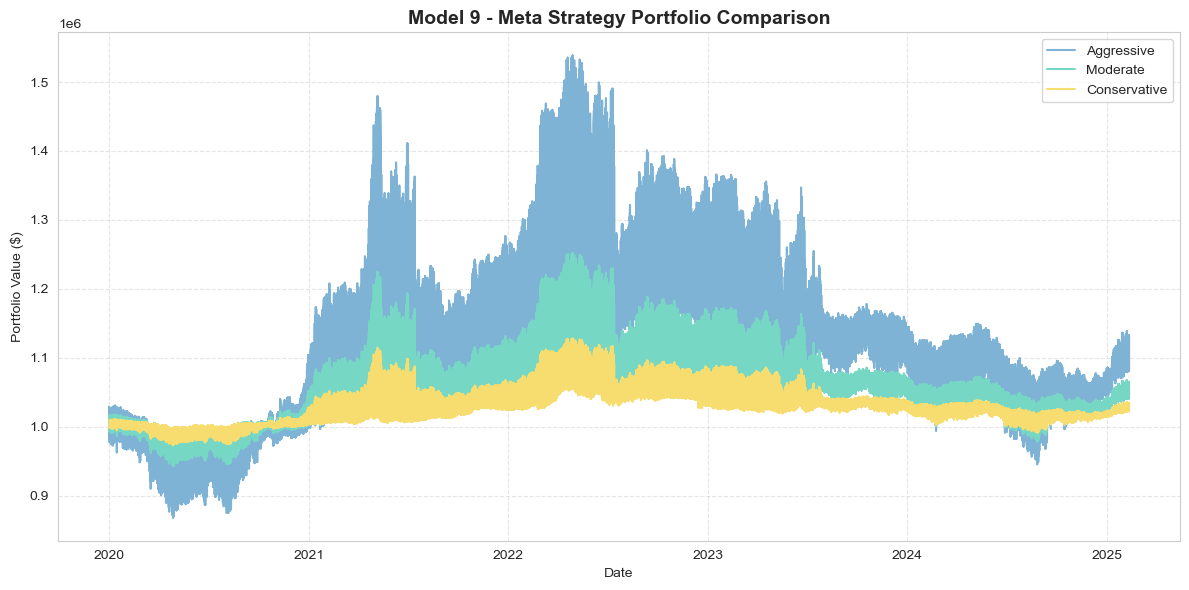

In [42]:
df_algo_meta = df_sentiment.copy()
df_algo_meta["Date"] = pd.to_datetime(df_algo_meta["Date"])

df_feat = prepare_features(df_algo_meta)
df_ext = generate_extreme_flags(df_feat)
df_score = calculate_signals(df_ext)
df_labeled = label_data(df_score)

features = [
    "MACD_Signal", "SMA_200", "SMA_20", "BB_Lower", "MACD", "SMA_50",
    "BB_Upper", "Fib_38.2", "Fib_61.8", "Fib_50", "Stochastic_%K", "RSI",
    "Global_Weather_Impact_Score", "Seasonal_Weather_Impact_Score"
]
df_labeled = df_labeled.dropna(subset=features + ["Signal"])

train = df_labeled[df_labeled["Date"].dt.year <= 2014]
val   = df_labeled[(df_labeled["Date"].dt.year >= 2015) & (df_labeled["Date"].dt.year <= 2019)]
test  = df_labeled[df_labeled["Date"].dt.year >= 2020]

X_train, y_train = train[features], train["Signal"]
X_val, y_val     = val[features], val["Signal"]
X_test, y_test   = test[features], test["Signal"]

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

model = train_rf(X_train, y_train)

print("\nValidation Report:")
print(classification_report(y_val, model.predict(X_val), zero_division=0))

print("\nTest Report:")
print(classification_report(y_test, model.predict(X_test), zero_division=0))

strategy_params = {
    "Aggressive": {
        "conf_thresh": 0.5, "max_allocation": 0.4,
        "min_holding_days": 5, "vol_quantile": 0.99
    },
    "Moderate": {
        "conf_thresh": 0.65, "max_allocation": 0.2,
        "min_holding_days": 10, "vol_quantile": 0.95
    },
    "Conservative": {
        "conf_thresh": 0.8, "max_allocation": 0.1,
        "min_holding_days": 15, "vol_quantile": 0.90
    }
}


pastel_colors = {
    "Aggressive": "#7FB3D5",   
    "Moderate": "#76D7C4",
    "Conservative": "#F7DC6F" 
}

plt.figure(figsize=(12, 6))

for name, params in strategy_params.items():
    result_df, trades = backtest_strategy(test.copy(), model, **params)
    result_df = result_df[np.isfinite(result_df["Portfolio_Value"])]

    initial_capital = 1_000_000
    final_portfolio_value = result_df["Portfolio_Value"].iloc[-1]
    total_return = final_portfolio_value - initial_capital
    roi_percentage = (total_return / initial_capital) * 100

    sharpe, max_dd, roi, pf, wl = evaluate(result_df)

    print(f"\n {name.upper()} STRATEGY PERFORMANCE:")
    print(f"Initial Capital: ${initial_capital:,.2f}")
    print(f"Final Portfolio Value: ${final_portfolio_value:,.2f}")
    print(f"Total Return: ${total_return:,.2f}")
    print(f"ROI: {roi_percentage:.2f}%")
    print(f"Sharpe Ratio: {sharpe}")
    print(f"Max Drawdown: {max_dd:.2f}%")
    print(f"Profit Factor: {pf:.2f}")
    print(f"Win/Loss Ratio: {wl:.2f}")

    plt.plot(result_df["Date"], result_df["Portfolio_Value"], label=name, color=pastel_colors[name])

plt.title("Model 9 - Meta Strategy Portfolio Comparison", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()



## Version 10 - Aggressive long-term strategy

In [43]:
def detect_regime(row):
    macd_spread = row["MACD"] - row["MACD_Signal"]
    is_trending_up = macd_spread > 0
    is_low_volatility = row["Volatility"] < row["Volatility_Mean"]
    is_positive_sentiment = row["Average_Sentiment"] > 0.2
    is_negative_sentiment = row["Average_Sentiment"] < -0.2

    if is_low_volatility and is_trending_up and is_positive_sentiment:
        return "Aggressive"
    elif is_negative_sentiment or row["Volatility"] > row["Volatility_Mean"] * 1.5:
        return "Conservative"
    else:
        return "Moderate"

def backtest_regime_switching(df, model):
    df = df.copy()

    features = [
        "MACD_Signal", "SMA_200", "SMA_20", "BB_Lower", "MACD", "SMA_50",
        "BB_Upper", "Fib_38.2", "Fib_61.8", "Fib_50", "Stochastic_%K", "RSI",
        "Global_Weather_Impact_Score", "Seasonal_Weather_Impact_Score",
        "Average_Sentiment", "Volatility"
    ]

    df["Volatility_Mean"] = df["Volatility"].rolling(60, min_periods=1).mean()
    df["Regime"] = df.apply(detect_regime, axis=1)

    strategy_params = {
        "Aggressive": {"conf_thresh": 0.55, "max_allocation": 0.25, "min_holding_days": 5},
        "Moderate": {"conf_thresh": 0.65, "max_allocation": 0.20, "min_holding_days": 10},
        "Conservative": {"conf_thresh": 0.75, "max_allocation": 0.10, "min_holding_days": 15}
    }

    df["Portfolio_Value"] = np.nan
    df["Position"] = 0
    df["Cash"] = 1_000_000
    position, cash = 0, 1_000_000
    holding_days = 0
    contract_size = 100

    proba = model.predict_proba(df[features])
    pred = model.predict(df[features])
    max_conf = proba.max(axis=1)
    df["RF_Signal"] = np.where(max_conf >= 0.5, pred, 0)

    df["Final_Buy"] = df["Buy_Signal"] & (df["RF_Signal"] == 1)
    df["Final_Sell"] = df["Sell_Signal"] & (df["RF_Signal"] == -1)

    trades = []

    for i, row in df.iterrows():
        regime = row["Regime"]
        params = strategy_params[regime]

        price = row["Price"]
        max_contracts = int((cash * params["max_allocation"]) // (price * contract_size))

        if row["Final_Sell"] and position > 0 and holding_days >= params["min_holding_days"]:
            cash += position * price * contract_size
            trades.append({"Date": row["Date"], "Action": f"Sell ({regime})", "Price": price, "Contracts": position})
            position = 0
            holding_days = 0

        elif row["Final_Buy"] and position == 0 and max_contracts > 0 and holding_days >= params["min_holding_days"]:
            cost = max_contracts * price * contract_size
            if cost <= cash:
                position = max_contracts
                cash -= cost
                trades.append({"Date": row["Date"], "Action": f"Buy ({regime})", "Price": price, "Contracts": position})
                holding_days = 0

        portfolio_value = cash + position * price * contract_size
        df.at[i, "Portfolio_Value"] = portfolio_value
        df.at[i, "Cash"] = cash
        df.at[i, "Position"] = position
        holding_days += 1

    return df.dropna(subset=["Portfolio_Value"]), pd.DataFrame(trades)

def evaluate(df):
    df = df.copy()
    df["Daily_Return"] = df["Portfolio_Value"].pct_change()
    sharpe = df["Daily_Return"].mean() / df["Daily_Return"].std() * np.sqrt(252)
    max_dd = ((df["Portfolio_Value"] / df["Portfolio_Value"].cummax()) - 1).min() * 100
    roi = (df["Portfolio_Value"].iloc[-1] - df["Portfolio_Value"].iloc[0]) / df["Portfolio_Value"].iloc[0] * 100
    return round(sharpe, 2), round(max_dd, 2), round(roi, 2)

def plot_portfolio(df):
    plt.figure(figsize=(12, 6))
    plt.plot(df["Date"], df["Portfolio_Value"], label="Portfolio Value", color="#779ECB")
    plt.title("Model 10")
    plt.xlabel("Date"); plt.ylabel("Portfolio Value ($)")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend(); plt.tight_layout(); plt.show()


Train shape: (46791, 16)
Validation shape: (18434, 16)
Test shape: (18558, 16)

Validation Report:
              precision    recall  f1-score   support

          -1       0.66      0.66      0.66      7882
           0       0.25      0.19      0.22      2680
           1       0.71      0.78      0.75      7872

    accuracy                           0.64     18434
   macro avg       0.54      0.54      0.54     18434
weighted avg       0.62      0.64      0.63     18434


Test Report:
              precision    recall  f1-score   support

          -1       0.63      0.74      0.68      7954
           0       0.27      0.13      0.18      2593
           1       0.71      0.70      0.70      8011

    accuracy                           0.64     18558
   macro avg       0.54      0.52      0.52     18558
weighted avg       0.61      0.64      0.62     18558


ALGO 3.0 (Regime Switching) PERFORMANCE:
Sharpe Ratio: 0.16
Max Drawdown: -15.65%
ROI: 2.61%

Capital Overview:
Initial Capi

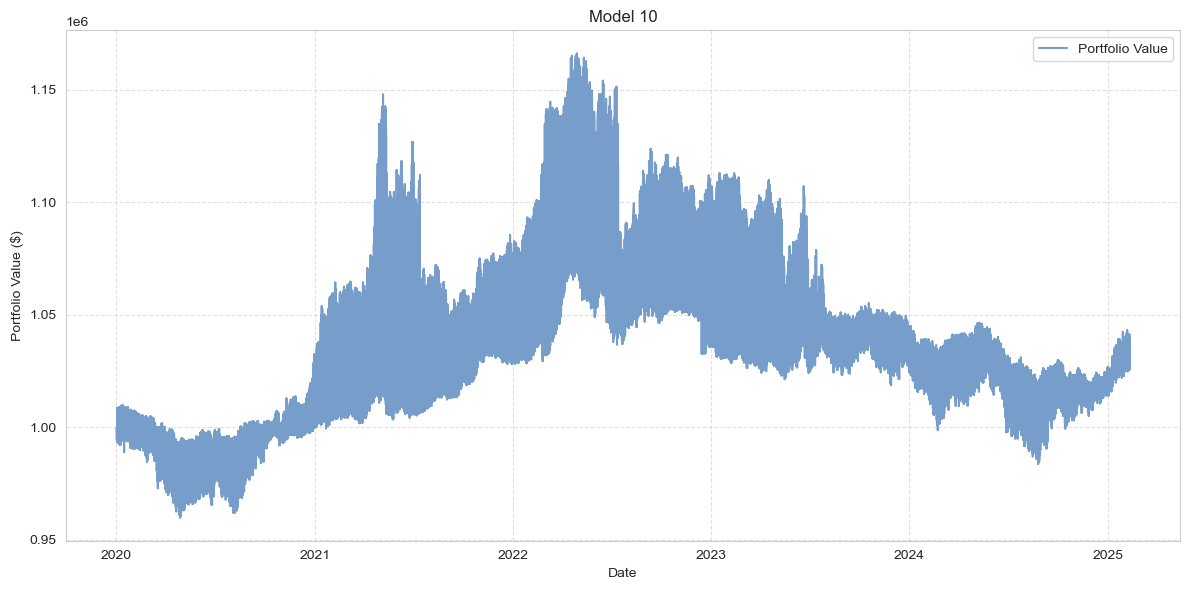

Trade log saved to 'algo3_0_regime_trades.xlsx'


In [44]:
df_algo30 = df_sentiment.copy()
df_algo30["Date"] = pd.to_datetime(df_algo30["Date"])

df_feat = prepare_features(df_algo30)
df_ext = generate_extreme_flags(df_feat)
df_score = calculate_signals(df_ext)
df_labeled = label_data(df_score)

features = [
    "MACD_Signal", "SMA_200", "SMA_20", "BB_Lower", "MACD", "SMA_50",
    "BB_Upper", "Fib_38.2", "Fib_61.8", "Fib_50", "Stochastic_%K", "RSI",
    "Global_Weather_Impact_Score", "Seasonal_Weather_Impact_Score",
    "Average_Sentiment", "Volatility"
]

df_labeled = df_labeled.dropna(subset=features + ["Signal"])

train = df_labeled[df_labeled["Date"].dt.year <= 2014]
val   = df_labeled[(df_labeled["Date"].dt.year >= 2015) & (df_labeled["Date"].dt.year <= 2019)]
test  = df_labeled[df_labeled["Date"].dt.year >= 2020]

X_train, y_train = train[features], train["Signal"]
X_val, y_val     = val[features], val["Signal"]
X_test, y_test   = test[features], test["Signal"]

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

model = train_rf(X_train, y_train)

from sklearn.metrics import classification_report

print("\nValidation Report:")
print(classification_report(y_val, model.predict(X_val), zero_division=0))

print("\nTest Report:")
print(classification_report(y_test, model.predict(X_test), zero_division=0))

df_backtest, trade_log = backtest_regime_switching(test.copy(), model)

sharpe, max_dd, roi = evaluate(df_backtest)

print("\nALGO 3.0 (Regime Switching) PERFORMANCE:")
print(f"Sharpe Ratio: {sharpe}")
print(f"Max Drawdown: {max_dd:.2f}%")
print(f"ROI: {roi:.2f}%")

initial_capital = 1_000_000
final_portfolio_value = df_backtest["Portfolio_Value"].iloc[-1]
total_return = final_portfolio_value - initial_capital
roi_percentage = (total_return / initial_capital) * 100

df_backtest["Daily_Return"] = df_backtest["Portfolio_Value"].pct_change()
gains = df_backtest[df_backtest["Daily_Return"] > 0]["Daily_Return"].sum()
losses = -df_backtest[df_backtest["Daily_Return"] < 0]["Daily_Return"].sum()
profit_factor = gains / losses if losses > 0 else np.nan
win_loss_ratio = (df_backtest["Daily_Return"] > 0).sum() / max((df_backtest["Daily_Return"] < 0).sum(), 1)

print("\nCapital Overview:")
print(f"Initial Capital: ${initial_capital:,.2f}")
print(f"Final Portfolio Value: ${final_portfolio_value:,.2f}")
print(f"Total Return: ${total_return:,.2f}")
print(f"Return on Investment (ROI): {roi_percentage:.2f}%")
print(f"Profit Factor: {profit_factor:.2f}")
print(f"Win/Loss Ratio: {win_loss_ratio:.2f}")


plot_portfolio(df_backtest)

trade_log.to_excel("algo3_0_regime_trades.xlsx", index=False)
print("Trade log saved to 'algo3_0_regime_trades.xlsx'")
